# Case study: How does a bike share navigate speedy success?

# Cyclistic Bike-Share Data Analysis

## 1. Project Context

Cyclistic is a fictional bike-share company operating in Chicago. The company launched its bike-share service in 2016 and has since expanded to a fleet of 5,824 bicycles and 692 docking stations throughout the city. Customers can unlock a bike at one station and return it to another station within the network.

Cyclistic offers several pricing options, including single-ride passes, full-day passes, and annual memberships. Customers using single-ride or full-day passes are classified as casual riders, while customers with annual memberships are classified as members.

The marketing team has identified annual members as a more profitable customer segment. Therefore, Cyclistic's marketing strategy aims to increase the number of annual memberships by converting existing casual riders into members.

The marketing team believes that casual riders are a particularly valuable target because they are already familiar with Cyclistic and have demonstrated a willingness to use its services. However, before developing a targeted marketing campaign, the company needs to understand how casual riders and annual members use the bike-share service differently.

This project analyzes Cyclistic's historical trip data to identify differences in riding behavior between these two customer segments. The analysis focuses on factors such as ride duration, ride patterns, bike type, and usage behavior to identify insights that could support a data-driven marketing strategy.

### 1.1 Role in the Project

In this case study, I work as a Junior Data Analyst on Cyclistic's marketing analytics team. My responsibility is to prepare and analyze the historical trip data, identify meaningful behavioral patterns, and translate those findings into insights that can support the marketing team's decision-making.

### 1.2 Analytical Approach

The project follows the six stages of the data analysis process:

1. **Ask** – Define the business problem, objective, and analytical questions.
2. **Prepare** – Collect, inspect, and understand the available Cyclistic datasets.
3. **Process** – Clean, validate, transform, and combine the data to prepare it for analysis.
4. **Analyze** – Compare the behavior of casual riders and annual members to identify meaningful patterns.
5. **Share** – Present the findings through clear visualizations and an evidence-based narrative.
6. **Act** – Develop recommendations based on the findings to support Cyclistic's marketing strategy.

## 2. Ask

### 2.1 Business Problem

Cyclistic wants to increase the number of annual memberships because annual members are more profitable than casual riders. The marketing team believes that understanding how casual riders and annual members use Cyclistic bikes differently can help identify opportunities to convert casual riders into annual members.

The main challenge is therefore to identify meaningful differences in riding behavior between these two customer groups and determine how those differences can be used to support targeted marketing strategies.

### 2.2 Business Objective

The objective of this analysis is to understand the behavioral differences between casual riders and annual members and use these insights to develop data-driven recommendations for increasing the conversion of casual riders into annual members.

The analysis focuses on identifying differences in:

* Ride frequency
* Ride duration
* Bike type usage
* Riding patterns over time
* Potential differences in usage behavior that could support marketing strategies

### 2.3 Business Question

The primary business question for this analysis is:

**How do casual riders and annual members use Cyclistic bikes differently, and how can these differences be used to develop strategies to convert casual riders into annual members?**

To answer this question, the analysis will examine the following supporting questions:

**Overall Usage**
- Who uses Cyclistic bikes more frequently: casual riders or annual members?
- Which months have the highest and lowest levels of bike usage?
- Which days of the week have the highest levels of bike usage?
- At what times of day are Cyclistic bikes used most frequently?

**Ride Behavior**
- How long do rides last for each type of user?
- Do casual riders and annual members have different riding patterns?
- Are there specific times of day when casual riders use Cyclistic bikes particularly frequently?

**Bike and Station Usage**
- Which types of bikes are preferred by casual riders and annual members?
- Which stations are most frequently used by each type of user?
- Are there differences in station usage between casual riders and annual members?

**Business Opportunity**
- What behavioral patterns distinguish casual riders from annual members?
- Which of these patterns could be used to develop strategies for converting casual riders into annual members?

## 3. Prepare

### 3.1 Data Source

The Cyclistic trip data can be accessed through the official Divvy trip data repository:

[Divvy Trip Data](https://divvy-tripdata.s3.amazonaws.com/index.html?utm_source=chatgpt.com)

The dataset was made available by Motivate International Inc. under the following data license agreement:

[Divvy Data License Agreement](https://divvybikes.com/data-license-agreement?utm_source=chatgpt.com)

The data is provided as monthly CSV files identified by year and month. These datasets are structured data organized into rows and columns, with each row representing an individual bike ride.

For this analysis, the 12 monthly files covering **August 2025 through July 2026** were used. This period provides one complete year of ride data and allows seasonal, monthly, weekly, and time-of-day patterns to be examined.

### 3.2 Data Structure

The original datasets contain information about each ride, including the bicycle type, start and end times, station information, geographic coordinates, and customer type.

The main variables are described below:

| Column               | Description                           | Statistical Type               |
| -------------------- | ------------------------------------- | ------------------------------ |
| `ride_id`            | Unique identifier of the ride         | Categorical - Nominal          |
| `rideable_type`      | Type of bicycle used                  | Categorical - Nominal          |
| `started_at`         | Date and time when the ride started   | Temporal - Datetime            |
| `ended_at`           | Date and time when the ride ended     | Temporal - Datetime            |
| `start_station_name` | Name of the starting station          | Categorical - Nominal          |
| `start_station_id`   | Identifier of the starting station    | Categorical - Nominal          |
| `end_station_name`   | Name of the ending station            | Categorical - Nominal          |
| `end_station_id`     | Identifier of the ending station      | Categorical - Nominal          |
| `start_lat`          | Latitude of the starting location     | Quantitative - Continuous      |
| `start_lng`          | Longitude of the starting location    | Quantitative - Continuous      |
| `end_lat`            | Latitude of the ending location       | Quantitative - Continuous      |
| `end_lng`            | Longitude of the ending location      | Quantitative - Continuous      |
| `member_casual`      | Customer type: member or casual rider | Categorical - Nominal / Binary |

### 3.3 Tools Used

The main technologies and libraries used were:

* **Python** – Data processing and analysis
* **Pandas** – Data manipulation, cleaning, validation, and aggregation
* **Jupyter Notebook** – Interactive analysis and documentation
* **VS Code** – Development environment

Pandas was particularly useful because the project contains several million ride records, making programmatic data cleaning and validation more efficient and reproducible than manually inspecting the datasets.

## 4. Process – Data Cleaning and Validation

The purpose of the Process stage was to clean, transform, and validate the Cyclistic trip data before conducting the analysis.

The 12 monthly datasets were processed systematically using Python and Pandas. The process began with importing the required libraries and loading the source files, followed by an initial inspection of their structure and quality. A cleaning and validation plan was then used to guide the subsequent transformations and checks.

### 4.1 Import Libraries

In [66]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Python:", sys.version)
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)


pd.set_option('display.max_rows', None)

Python: 3.14.3 (main, Feb  3 2026, 15:32:20) [Clang 17.0.0 (clang-1700.6.3.2)]
Pandas: 3.0.5
NumPy: 2.5.2


### 4.2 Load the Monthly Datasets

The Cyclistic trip data was provided as 12 monthly datasets covering the period from August 2025 through July 2026. Each file was loaded into a separate Pandas DataFrame and stored in a dictionary to facilitate systematic processing and comparison. The monthly datasets were identified using keys corresponding to their respective months.

In [2]:
aug25 = pd.read_csv('../data/raw/202508-divvy-tripdata.csv')
sep25 = pd.read_csv('../data/raw/202509-divvy-tripdata.csv')
oct25 = pd.read_csv('../data/raw/202510-divvy-tripdata.csv')
nov25 = pd.read_csv('../data/raw/202511-divvy-tripdata.csv')
dec25 = pd.read_csv('../data/raw/202512-divvy-tripdata.csv')
jan26 = pd.read_csv('../data/raw/202601-divvy-tripdata.csv')
feb26 = pd.read_csv('../data/raw/202602-divvy-tripdata.csv')
mar26 = pd.read_csv('../data/raw/202603-divvy-tripdata.csv')
apr26 = pd.read_csv('../data/raw/202604-divvy-tripdata.csv')
may26 = pd.read_csv('../data/raw/202605-divvy-tripdata.csv')
jun26 = pd.read_csv('../data/raw/202606-divvy-tripdata.csv')
jul26 = pd.read_csv('../data/raw/202607-divvy-tripdata.csv')



In [3]:
tables = {
    'aug25': aug25,
    'sep25': sep25,
    'oct25': oct25,
    'nov25': nov25,
    'dec25': dec25,
    'jan26': jan26,
    'feb26': feb26,
    'mar26': mar26,
    'apr26': apr26,
    'may26': may26,
    'jun26': jun26,
    'jul26': jul26
}

Processing the monthly datasets separately allowed potential data-quality issues to be identified at their original source before combining the files.

### 4.3 Initial Dataset Inspection

The purpose of this step was to understand the structure of the data and identify potential data-quality issues that required further investigation.

The inspection focused on the following aspects:

* Number of rows and columns.
* Column names.
* Data types.
* Presence of missing values.
* Duplicate records.
* Basic information about the structure of each dataset.

### 4.3.1 Verify Monthly Dataset Structure

The structure of the datasets was compared to ensure consistency across all 12 monthly files.

The `aug25` dataset was used as the reference, and the column names and order of each DataFrame were compared against it.

In [4]:
# Take the columns from the first table as reference ('aug25')
reference_columns = list(tables['aug25'].columns)

# Verify all other tables have exactly the same columns in the same order
all_matching = all(list(df.columns) == reference_columns for df in tables.values())

if all_matching:
    print(f"Perfect! All tables have the same columns in the same order.\nThe columns are {reference_columns}")
else:
    print("Error: There are differences in the columns or their order.")

Perfect! All tables have the same columns in the same order.
The columns are ['ride_id', 'rideable_type', 'started_at', 'ended_at', 'start_station_name', 'start_station_id', 'end_station_name', 'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng', 'member_casual']


The initial inspection confirmed that the monthly datasets followed the same general structure (the same 13 original columns in the same order) and contained the expected variables for the analysis. 

### 4.3.2 Table and Column Profiling

A table- and column-level profiling process was performed to assess the initial quality and structure of the data.


**Table Profiling**

At the table level, the profiling focused on the dimensions of each dataset, the presence of missing values, and duplicate records.

In [5]:
profiling = []

for name, df in tables.items():
    profiling.append({
        "table": name,
        "rows": df.shape[0],
        "columns": df.shape[1],
        "null_values": df.isna().sum().sum(), 
        "duplicate_rows": df.duplicated().sum() 
    })

profiling_df = pd.DataFrame(profiling)

profiling_df

,table,rows,columns,null_values,duplicate_rows
0,aug25,790177,13,725148,0
1,sep25,714759,13,642726,0
2,oct25,646039,13,598062,0
3,nov25,356628,13,317066,0
4,dec25,140534,13,114186,0
5,jan26,137787,13,104688,0
6,feb26,201450,13,134118,0
7,mar26,317037,13,241632,0
8,apr26,448252,13,373270,0
9,may26,653704,13,559558,0


**Column Profiling**

At the column level, the profiling was used to examine data types, unique values, the presence of missing values, duplicate records and the general characteristics of individual variables.

In [6]:
column_profiling = []

for table_name, df in tables.items():
    for column in df.columns:
            series = df[column]
    
            profile = {
                "table": table_name,
                "column": column,
                "dtype": str(series.dtype),
                "non_null": series.notna().sum(),
                "null": series.isna().sum(),
                "null_percentage": round(((series.isna().sum()) / len(series)) * 100,2),
                "unique_values": series.nunique(dropna = True),
                "duplicate_values": series.duplicated().sum()  
            }
    
            column_profiling.append(profile)

column_profiling_df = pd.DataFrame(column_profiling)

column_profiling_df  

,table,column,dtype,non_null,null,null_percentage,unique_values,duplicate_values
0,aug25,ride_id,str,790177,0,0.00,790177,0
1,aug25,rideable_type,str,790177,0,0.00,2,790175
2,aug25,started_at,str,790177,0,0.00,789969,208
3,aug25,ended_at,str,790177,0,0.00,789931,246
4,aug25,start_station_name,str,613056,177121,22.42,1390,788786
5,aug25,start_station_id,str,613056,177121,22.42,1397,788779
6,aug25,end_station_name,str,605417,184760,23.38,1388,788788
7,aug25,end_station_id,str,605417,184760,23.38,1394,788782
8,aug25,start_lat,float64,790177,0,0.00,22059,768118
9,aug25,start_lng,float64,790177,0,0.00,22023,768154


#### **Observations:**

#### **Identifier Integrity**

The `ride_id` column did not contain null values or duplicated values. In addition, the number of non-null values matched the number of unique values. Therefore, `ride_id` showed adequate integrity as a unique ride identifier within each monthly file.

#### **Date and Time Variables**

The `started_at` and `ended_at` columns were initially stored as string values. Therefore, these variables required conversion to a datetime format before performing calculations involving dates, times, and ride duration.

#### **Missing Values**

The following columns contained null values:

* `start_station_name`
* `start_station_id`
* `end_station_name`
* `end_station_id`
* `start_lat`
* `start_lng`
* `end_lat`
* `end_lng`

The presence of missing values was evaluated in relation to the business question:

**How do casual riders and annual members use Cyclistic bikes differently, and how can these differences be used to design a strategy to convert casual riders into annual members?**

To address this business question, the analysis primarily requires information such as `member_casual`, `started_at`, `ended_at`, and `rideable_type`, as well as derived variables such as ride duration, month, day of the week, and time of day.

Station-related information is useful for specific analyses of ride start and end locations, but it is not required for all analytical objectives. Because these variables contain a significant proportion of missing values, records with missing station information were retained rather than removed. Missing station information does not invalidate the ride record or affect analyses that do not depend on station-related variables.

#### **Repeated Values and Expected Duplicates**

Repeated values were observed in the following columns:

* `rideable_type`
* `started_at`
* `ended_at`
* `start_station_name`
* `start_station_id`
* `end_station_name`
* `end_station_id`
* `start_lat`
* `start_lng`
* `end_lat`
* `end_lng`
* `member_casual`

The presence of repeated values was evaluated according to the nature and expected behavior of each variable. Repeated values are expected in several columns because multiple rides can share the same characteristics.

For example, categorical variables such as `rideable_type` and `member_casual` contain a limited number of possible categories, making repeated values normal. Similarly, multiple rides may start or end at the same station or occur at similar times.

Therefore, repeated values within individual columns were not considered a data-quality issue by themselves.

Column-level repeated values were distinguished from **duplicate records**, which were evaluated separately using complete-row duplication and `ride_id` duplication checks.

#### **Profiling-Based Data Quality Decisions**

The profiling results helped determine which findings required corrective action and which represented expected characteristics of the dataset.

The absence of null or repeated `ride_id` values supported its use as the unique identifier for individual rides. The `started_at` and `ended_at` variables required conversion to datetime format before calculating ride duration and extracting temporal variables for analysis.

Missing station information was retained because it did not invalidate the records or prevent the analysis of the primary business question. Repeated values in categorical and descriptive columns were considered expected and were not removed.

These findings were used to define the subsequent data cleaning and validation steps.

### 4.4 Data Cleaning and Validation Plan

Based on the initial inspection, the following cleaning and validation plan was established:

| Step | Variable                                       | Action                               | Justification                                                                                                         |
| ---- | ---------------------------------------------- | ------------------------------------ | --------------------------------------------------------------------------------------------------------------------- |
| 1    | `started_at`                                   | Convert to datetime                  | The variable is initially stored as text and is required to calculate ride duration and extract month, day, and hour. |
| 2    | `ended_at`                                     | Convert to datetime                  | Allows the duration of each ride to be calculated.                                                                    |
| 3    | `started_at`, `ended_at`                       | Check for invalid dates              | Identifies records that cannot be reliably used for time-based calculations.                                          |
| 4    | `ended_at`, `started_at`                       | Verify that `ended_at >= started_at` | A ride should not end before it starts.                                                                               |
| 5    | `rideable_type`                                | Validate categories                  | Confirms that only the expected bicycle types are present.                                                            |
| 6    | `member_casual`                                | Validate categories                  | Confirms that records correspond to the expected customer types.                                                      |
| 7    | `start_lat`, `start_lng`, `end_lat`, `end_lng` | Validate ranges                      | Identifies geographically invalid coordinate values.                                                                  |
| 8    | Station information                            | Retain missing values                | Missing station information does not necessarily invalidate a ride and is not required for all analyses.              |


This plan was used as a guide for the subsequent data-cleaning and validation procedures. Each potential issue was investigated before deciding whether records should be corrected, retained, or removed.

### 4.5 Convert Date and Time Variables

The `started_at` and `ended_at` columns were initially stored as string values. Since these variables represent the start and end timestamps of each ride, they needed to be converted to a datetime format before performing calculations involving dates, times, and ride duration.

In [7]:
for table_name, df in tables.items():
    
    # Convert date columns to datetime
    df["started_at"] = pd.to_datetime(
        df["started_at"],
        errors="coerce"
    )
    
    df["ended_at"] = pd.to_datetime(
        df["ended_at"],
        errors="coerce"
    )

After the conversion, the data types of both columns were checked:

In [8]:

for table_name, df in tables.items():
    print(f"\n--- {table_name} ---")
    print(df[["started_at", "ended_at"]].dtypes)


--- aug25 ---
started_at    datetime64[us]
ended_at      datetime64[us]
dtype: object

--- sep25 ---
started_at    datetime64[us]
ended_at      datetime64[us]
dtype: object

--- oct25 ---
started_at    datetime64[us]
ended_at      datetime64[us]
dtype: object

--- nov25 ---
started_at    datetime64[us]
ended_at      datetime64[us]
dtype: object

--- dec25 ---
started_at    datetime64[us]
ended_at      datetime64[us]
dtype: object

--- jan26 ---
started_at    datetime64[us]
ended_at      datetime64[us]
dtype: object

--- feb26 ---
started_at    datetime64[us]
ended_at      datetime64[us]
dtype: object

--- mar26 ---
started_at    datetime64[us]
ended_at      datetime64[us]
dtype: object

--- apr26 ---
started_at    datetime64[us]
ended_at      datetime64[us]
dtype: object

--- may26 ---
started_at    datetime64[us]
ended_at      datetime64[us]
dtype: object

--- jun26 ---
started_at    datetime64[us]
ended_at      datetime64[us]
dtype: object

--- jul26 ---
started_at    datetime64[us]


The columns were successfully converted to the `datetime64[us]` data type.

This transformation was necessary because the next step involved calculating the duration of each ride by subtracting the start timestamp from the end timestamp.

However, converting a column to datetime can produce `NaT` (Not a Time) values when an input value cannot be interpreted as a valid datetime. Therefore, the converted columns were checked for `NaT` values before proceeding with the ride-duration calculation.

### 4.5.1 Check for Invalid Date Values (NaT)


In [9]:
invalid_dates = []

for table_name, df in tables.items():

    invalid = {
        "table": table_name,
        "invalid_started_at": df["started_at"].isna().sum(),
        "invalid_ended_at": df["ended_at"].isna().sum()
    }

    invalid_dates.append(invalid)

invalid_dates_df = pd.DataFrame(invalid_dates)

invalid_dates_df   

,table,invalid_started_at,invalid_ended_at
0,aug25,0,0
1,sep25,0,0
2,oct25,0,0
3,nov25,0,0
4,dec25,0,0
5,jan26,0,0
6,feb26,0,0
7,mar26,0,0
8,apr26,0,0
9,may26,0,0


The results showed that no invalid values were found in `started_at` or `ended_at` across the 12 monthly datasets. Therefore, all records contain valid datetime values suitable for subsequent duration and temporal analyses.

### 4.6 Create ride_length

A new variable called `ride_length` was created to represent ride duration in minutes. The `ride_length` variable was calculated in minutes by subtracting `started_at` from `ended_at`. The resulting `timedelta` values were converted to seconds using `.dt.total_seconds()` and then divided by 60.


In [10]:
for table_name, df in tables.items():

    # Calculate ride duration in minutes
    df["ride_length"] = (
        df["ended_at"] - df["started_at"]
    ).dt.total_seconds() / 60

After creating the variable, its basic characteristics were reviewed to identify potentially invalid values, including negative, zero, or missing ride durations.

### 4.6.1 Identify Negative Ride Durations

After calculating `ride_length`, the resulting values were checked for negative durations. A negative ride duration occurs when the recorded `ended_at` timestamp is earlier than the corresponding `started_at` timestamp.

Negative values cannot represent a valid ride duration and may indicate an inconsistency in the recorded timestamps. Therefore, these records were identified before making any corrections.

The following code was used to count negative ride durations in each monthly dataset:

In [11]:
for table_name, df in tables.items():
    
    # Check for negative ride duration
    negative_duration = (df["ride_length"] < 0).sum()
    
    print(f"{table_name}: {negative_duration} records with negative ride_length")

aug25: 0 records with negative ride_length
sep25: 0 records with negative ride_length
oct25: 0 records with negative ride_length
nov25: 29 records with negative ride_length
dec25: 0 records with negative ride_length
jan26: 0 records with negative ride_length
feb26: 0 records with negative ride_length
mar26: 0 records with negative ride_length
apr26: 0 records with negative ride_length
may26: 0 records with negative ride_length
jun26: 0 records with negative ride_length
jul26: 0 records with negative ride_length


This validation identified **29 records with negative ride duration (`ride_length`) in November 2025**. 

Because negative ride durations are not valid under the expected chronological sequence of a trip, these records were not immediately removed. Instead, they were investigated individually to determine the cause of the discrepancy before deciding whether a correction was appropriate.


### 4.6.2 Investigate Negative Durations in November 2025

After identifying 29 records with negative `ride_length` values, the affected records were examined individually to determine the cause of the inconsistency.

The investigation focused on comparing the recorded `started_at` and `ended_at` timestamps and reviewing the corresponding ride information. The objective was to determine whether the negative durations resulted from invalid records or from an inconsistency that could be corrected without removing the rides.

The affected records were first extracted for inspection:

In [12]:
nov25_invalid = tables["nov25"][
    tables["nov25"]["ride_length"] < 0].copy()

print(f"Negative ride_length records: {len(nov25_invalid)}")


nov25_invalid[
        [
            "ride_id",
            "started_at",
            "ended_at",
            "ride_length",
            "rideable_type",
            "member_casual"
        ]
    ]

Negative ride_length records: 29


,ride_id,started_at,ended_at,ride_length,rideable_type,member_casual
25121,5D010AFEA6850513,2025-11-02 01:52:37.475,2025-11-02 01:13:24.728,-39.212450,electric_bike,member
26669,D1E5316AD88ECD45,2025-11-02 01:50:39.702,2025-11-02 01:14:04.164,-36.592300,classic_bike,casual
28663,3AF2F8908C9386F8,2025-11-02 01:57:57.512,2025-11-02 01:33:52.225,-24.088117,classic_bike,member
43559,19386939ECD81B33,2025-11-02 01:55:34.399,2025-11-02 01:21:31.873,-34.042100,electric_bike,member
51927,083534D28DA37F72,2025-11-02 01:17:57.001,2025-11-02 01:05:27.752,-12.487483,classic_bike,member
96512,4A659F1BB40EDBF7,2025-11-02 01:55:38.177,2025-11-02 01:04:35.315,-51.047700,electric_bike,casual
122065,DA5386E5759667EC,2025-11-02 01:51:31.704,2025-11-02 01:05:47.339,-45.739417,electric_bike,member
127523,985A3462DAACFFCF,2025-11-02 01:59:07.835,2025-11-02 01:05:19.214,-53.810350,classic_bike,member
147446,434E3D11ABA96891,2025-11-02 01:59:40.156,2025-11-02 01:08:51.303,-50.814217,electric_bike,casual
157264,9288498F5630E3AD,2025-11-02 01:49:48.360,2025-11-02 01:02:40.976,-47.123067,electric_bike,casual



During the investigation of the date and time variables, **29 records from November 2025** were identified in which `ended_at` was earlier than `started_at`. Upon analyzing these records, it was observed that all of them occurred on **November 2, 2025**, between approximately **1:00 a.m. and 2:00 a.m.** 

To provide additional context, the total number of rides recorded on November 2 was compared with the number of records containing negative durations.

In [13]:
nov25_nov2 = tables["nov25"][
    tables["nov25"]["started_at"].dt.date ==
    pd.Timestamp("2025-11-02").date()
]

print("Total rides on November 2, 2025:", len(nov25_nov2))

print(
    "Negative ride_length records on November 2, 2025:", len(nov25_invalid))

Total rides on November 2, 2025: 13748
Negative ride_length records on November 2, 2025: 29


Of the **13,748 rides recorded on that day**, only 29 exhibited this behavior, representing approximately **0.21% of the records**. 

The concentration of all negative-duration records within the same date and approximately the same one-hour period indicated a temporal pattern rather than randomly distributed timestamp inconsistencies.

The affected timestamps were consistent with the period in which the daylight-saving time transition occurred. Because the dataset contains naive datetime values without explicit timezone information, the records were investigated in the context of this temporal transition rather than automatically classified as data-entry errors.

The investigation indicated that the negative durations were associated with the daylight-saving time change and therefore required a specific correction before proceeding with subsequent ride-duration analyses.

The correction was applied only to the affected records, preserving the remaining ride information.

In [14]:
df = tables["nov25"]

# Identify rides affected by the time change
mask = (
    (df["started_at"].dt.date == pd.Timestamp("2025-11-02").date()) &
    (df["started_at"] > df["ended_at"])
)

# Add 60 minutes to the affected ride durations
df.loc[mask, "ride_length"] += 60

print("Affected records:", mask.sum())

Affected records: 29


The corrected records were then revalidated to confirm that the negative ride durations had been resolved without introducing new invalid values.

### 4.6.3 Revalidate Ride Duration

After correcting the negative `ride_length` values, the ride-duration variable was revalidated to confirm that the correction was successful and that no invalid duration values remained.

The validation checked for:

* Negative ride durations.
* Zero ride durations.
* Missing ride durations.

The following code was used:


In [15]:

ride_length_revalidated = []

for table_name, df in tables.items():

    ride_revalidated = {
        "table": table_name,
        "negative_duration": (df["ride_length"]<0).sum(),
        "zero_duration": (df["ride_length"] == 0).sum(),
        "null_durarion": (df["ride_length"].isna().sum())
    }

    ride_length_revalidated.append(ride_revalidated)

ride_length_revalidated_df = pd.DataFrame(ride_length_revalidated)

ride_length_revalidated_df


,table,negative_duration,zero_duration,null_durarion
0,aug25,0,0,0
1,sep25,0,0,0
2,oct25,0,0,0
3,nov25,0,0,0
4,dec25,0,0,0
5,jan26,0,0,0
6,feb26,0,0,0
7,mar26,0,0,0
8,apr26,0,0,0
9,may26,0,0,0


The results showed:

* **Negative `ride_length`: 0**
* **Zero `ride_length`: 0**
* **Null `ride_length`: 0**

These results confirmed that the identified negative ride durations had been resolved and that the `ride_length` variable was suitable for subsequent analysis.

This validation step also ensured that the correction did not create additional missing or zero-duration records.


### 4.6.4 Investigate Unusually Long Rides

After validating the basic ride-duration values, unusually long rides were investigated to identify potential data-quality issues.

A long ride does not necessarily represent an invalid observation. Therefore, records were not removed solely because they had a high `ride_length`. Instead, a threshold of **24 hours** was used to identify rides that required additional investigation.

The number of rides longer than 24 hours was calculated for each monthly dataset:

In [16]:
for table_name, df in tables.items():

    # Count rides longer than 24 hours
    long_rides = (df["ride_length"] > 24 * 60).sum()

    print(
        f"{table_name}: "
        f"{long_rides} rides longer than 24 hours"
    )

aug25: 702 rides longer than 24 hours
sep25: 618 rides longer than 24 hours
oct25: 599 rides longer than 24 hours
nov25: 337 rides longer than 24 hours
dec25: 125 rides longer than 24 hours
jan26: 191 rides longer than 24 hours
feb26: 117 rides longer than 24 hours
mar26: 266 rides longer than 24 hours
apr26: 354 rides longer than 24 hours
may26: 573 rides longer than 24 hours
jun26: 679 rides longer than 24 hours
jul26: 780 rides longer than 24 hours



The results showed that rides longer than 24 hours were present in every month. The monthly counts ranged from **117 to 780 records**, with higher counts in some months.

Because a 24-hour threshold identified a relatively large number of records, the longest rides were examined further rather than being automatically removed.

### 4.6.5 Investigate Rides Longer Than 25 Hours

As part of the ride duration validation, rides longer than 25 hours were investigated to determine whether they represented valid long-duration rides or possible time-related inconsistencies.

In [17]:
for table_name, df in tables.items():

    # Count rides longer than 25 hours
    over_25_hours = (df["ride_length"] > 25 * 60).sum()

    print(
        f"{table_name}: "
        f"{over_25_hours} rides longer than 25 hours"
    )

aug25: 0 rides longer than 25 hours
sep25: 0 rides longer than 25 hours
oct25: 0 rides longer than 25 hours
nov25: 0 rides longer than 25 hours
dec25: 0 rides longer than 25 hours
jan26: 0 rides longer than 25 hours
feb26: 0 rides longer than 25 hours
mar26: 10 rides longer than 25 hours
apr26: 0 rides longer than 25 hours
may26: 0 rides longer than 25 hours
jun26: 0 rides longer than 25 hours
jul26: 0 rides longer than 25 hours


The validation identified **10 rides in the March 2026 dataset** with durations longer than 25 hours.

In [18]:
mar26_over_25 = tables["mar26"][
    tables["mar26"]["ride_length"] > 25 * 60
].copy()

print(
    mar26_over_25[
        [
            "ride_id",
            "started_at",
            "ended_at",
            "ride_length",
            "rideable_type",
            "member_casual"
        ]
    ]
)

                 ride_id              started_at                ended_at  \
22959   A679963188E41606 2026-03-07 14:40:43.466 2026-03-08 16:40:22.698   
67543   C82393BDD3070D5D 2026-03-07 16:07:09.988 2026-03-08 18:07:06.999   
67675   EB04F9C062AAAF6A 2026-03-07 09:33:18.048 2026-03-08 11:33:09.975   
139455  7CFD1B6B5319BB28 2026-03-07 12:20:32.025 2026-03-08 14:20:23.251   
139458  B35EFB4539BB4B2B 2026-03-07 02:41:16.669 2026-03-08 04:41:03.312   
141230  266FF1F3D3203623 2026-03-07 12:29:39.955 2026-03-08 14:29:33.587   
144024  FBBF2C15825C4E6F 2026-03-07 12:28:27.947 2026-03-08 14:28:06.578   
144704  250556580DD308BE 2026-03-07 23:51:38.812 2026-03-09 01:51:33.033   
145626  F2DADD2100A676E7 2026-03-07 09:43:11.203 2026-03-08 11:43:04.158   
183720  13769591C639EB0C 2026-03-07 12:45:52.881 2026-03-08 14:45:33.445   

        ride_length rideable_type member_casual  
22959   1559.653867  classic_bike        casual  
67543   1559.950183  classic_bike        casual  
67675   1559.

All 10 rides started on **March 7, 2026**, and ended on either March 8 or March 9. Their recorded durations were approximately **1,559.6 minutes**, equivalent to approximately 26 hours.

The affected rides were predominantly recorded as `classic_bike`, and the records included both `casual` and `member` users.

Because the calculated duration was approximately 26 hours, the one-hour difference was attributed to the daylight saving time change rather than to an actual ride lasting more than 25 hours. Therefore, the duration of these 10 rides was adjusted by subtracting one hour.

In [19]:
for table_name, df in tables.items():

    if table_name == "mar26":

        # Identify rides affected by the time change
        mask = (
            (df["started_at"].dt.date == pd.Timestamp("2026-03-07").date()) &
            (df["ride_length"] > 25 * 60)
        )

        # Subtract 60 minutes from the affected ride durations
        df.loc[mask, "ride_length"] -= 60


After the correction, the affected rides remained valid long-duration rides, but their calculated duration was no longer above the 25-hour threshold. The rides were retained because the timestamps themselves were valid and the unusually long duration was explained by the daylight saving time transition.

### 4.6.6 Revalidate Ride Duration

After correcting the rides affected by the daylight saving time transition, the `ride_length` variable was revalidated to ensure that no invalid or unexplained durations remained.

The following checks were performed:

In [20]:
for table_name, df in tables.items():

    negative_duration = (df["ride_length"] < 0).sum()
    zero_duration = (df["ride_length"] == 0).sum()
    over_25_hours = (df["ride_length"] > 25 * 60).sum()
    null_duration = df["ride_length"].isna().sum()

    print(
        f"{table_name}: "
        f"negative = {negative_duration}, "
        f"zero = {zero_duration}, "
        f"over_25h = {over_25_hours}, "
        f"null ride_length = {null_duration}"
    )

aug25: negative = 0, zero = 0, over_25h = 0, null ride_length = 0
sep25: negative = 0, zero = 0, over_25h = 0, null ride_length = 0
oct25: negative = 0, zero = 0, over_25h = 0, null ride_length = 0
nov25: negative = 0, zero = 0, over_25h = 0, null ride_length = 0
dec25: negative = 0, zero = 0, over_25h = 0, null ride_length = 0
jan26: negative = 0, zero = 0, over_25h = 0, null ride_length = 0
feb26: negative = 0, zero = 0, over_25h = 0, null ride_length = 0
mar26: negative = 0, zero = 0, over_25h = 0, null ride_length = 0
apr26: negative = 0, zero = 0, over_25h = 0, null ride_length = 0
may26: negative = 0, zero = 0, over_25h = 0, null ride_length = 0
jun26: negative = 0, zero = 0, over_25h = 0, null ride_length = 0
jul26: negative = 0, zero = 0, over_25h = 0, null ride_length = 0


These checks validate four conditions:

* **Negative durations:** rides where `ride_length` is less than 0.
* **Zero durations:** rides where the start and end timestamps are identical.
* **Null durations:** rides where `ride_length` could not be calculated.
* **Rides over 25 hours:** rides with a duration greater than 25 hours.

The validation confirmed that there were **no negative, zero, or null ride durations**, and that the 10 rides previously identified as exceeding 25 hours were no longer above this threshold after the daylight saving time correction.

This confirmed that the `ride_length` variable was ready for the next stage of data-quality analysis.

### 4.6.7 Investigate Very Short Rides

Very short rides were investigated to identify potential data-quality issues and determine whether extremely low ride durations represented invalid records or valid observations.

Rides with a duration of less than one minute were identified for each monthly dataset:


In [21]:
for table_name, df in tables.items():

    # Count rides shorter than one minute
    very_short_rides = (df["ride_length"] < 1).sum()

    print(
        f"{table_name}: "
        f"{very_short_rides:,} rides shorter than 1 minute"
    )

aug25: 22,938 rides shorter than 1 minute
sep25: 18,293 rides shorter than 1 minute
oct25: 17,016 rides shorter than 1 minute
nov25: 9,520 rides shorter than 1 minute
dec25: 3,961 rides shorter than 1 minute
jan26: 3,846 rides shorter than 1 minute
feb26: 4,022 rides shorter than 1 minute
mar26: 8,286 rides shorter than 1 minute
apr26: 12,420 rides shorter than 1 minute
may26: 17,769 rides shorter than 1 minute
jun26: 20,516 rides shorter than 1 minute
jul26: 22,315 rides shorter than 1 minute



A total of **22,938 very short rides** were identified in August 2025, with similar records found throughout the remaining months.

To better understand these records, the rides were divided into three duration ranges:

* Less than 10 seconds
* 10 to 30 seconds
* 30 to 60 seconds

In [22]:
for table_name, df in tables.items():

    # Count very short rides by duration range
    under_10_seconds = (df["ride_length"] < 10 / 60).sum()
    
    between_10_30_seconds = (
        (df["ride_length"] >= 10 / 60) &
        (df["ride_length"] < 30 / 60)
    ).sum()

    between_30_60_seconds = (
        (df["ride_length"] >= 30 / 60) &
        (df["ride_length"] < 1)
    ).sum()

    print(f"\n--- {table_name} ---")
    print(f"< 10 seconds: {under_10_seconds:,}")
    print(f"10–30 seconds: {between_10_30_seconds:,}")
    print(f"30–60 seconds: {between_30_60_seconds:,}")


--- aug25 ---
< 10 seconds: 4,945
10–30 seconds: 11,783
30–60 seconds: 6,210

--- sep25 ---
< 10 seconds: 3,878
10–30 seconds: 9,337
30–60 seconds: 5,078

--- oct25 ---
< 10 seconds: 3,123
10–30 seconds: 8,822
30–60 seconds: 5,071

--- nov25 ---
< 10 seconds: 1,695
10–30 seconds: 4,904
30–60 seconds: 2,921

--- dec25 ---
< 10 seconds: 922
10–30 seconds: 2,030
30–60 seconds: 1,009

--- jan26 ---
< 10 seconds: 994
10–30 seconds: 1,766
30–60 seconds: 1,086

--- feb26 ---
< 10 seconds: 1,283
10–30 seconds: 1,571
30–60 seconds: 1,168

--- mar26 ---
< 10 seconds: 2,227
10–30 seconds: 3,508
30–60 seconds: 2,551

--- apr26 ---
< 10 seconds: 3,638
10–30 seconds: 5,324
30–60 seconds: 3,458

--- may26 ---
< 10 seconds: 5,411
10–30 seconds: 7,081
30–60 seconds: 5,277

--- jun26 ---
< 10 seconds: 6,226
10–30 seconds: 8,374
30–60 seconds: 5,916

--- jul26 ---
< 10 seconds: 6,146
10–30 seconds: 9,419
30–60 seconds: 6,750


Sample records were then reviewed to determine whether these short durations were associated with invalid timestamps or other data-quality problems.

In [23]:
for table_name, df in tables.items():

    # Select rides shorter than 10 seconds
    very_short = df[df["ride_length"] < 10 / 60]

    print(f"\n--- {table_name} ---")
    print(
        very_short[
            [
                "ride_id",
                "rideable_type",
                "started_at",
                "ended_at",
                "ride_length",
                "member_casual"
            ]
        ].head(5)
    )


--- aug25 ---
              ride_id  rideable_type              started_at  \
33   78F8FB84E6F1F231  electric_bike 2025-08-27 23:41:30.052   
63   6E5DD1D9E948A7A1  electric_bike 2025-08-28 17:05:34.045   
161  ECE4C6CE5CCE8735  electric_bike 2025-08-08 18:45:01.990   
182  947E6B2AEC6C927A  electric_bike 2025-08-08 02:04:13.327   
192  6E90AB7B80A70FC8  electric_bike 2025-08-08 16:03:55.987   

                   ended_at  ride_length member_casual  
33  2025-08-27 23:41:38.697     0.144083        casual  
63  2025-08-28 17:05:42.074     0.133817        casual  
161 2025-08-08 18:45:04.606     0.043600        casual  
182 2025-08-08 02:04:20.851     0.125400        casual  
192 2025-08-08 16:03:57.432     0.024083        casual  

--- sep25 ---
              ride_id  rideable_type              started_at  \
19   4696CD0410B471C2  electric_bike 2025-09-22 11:40:08.360   
64   7916C32CFAF97EC1  electric_bike 2025-09-11 17:34:07.951   
169  A82A063292CCFD16  electric_bike 2025-09-30 17:

The review showed that the very short rides were primarily associated with **electric bikes** and included valid start and end timestamps. No evidence indicated that these records were caused by invalid dates or calculation errors.

Therefore, the rides shorter than one minute were considered **plausible records** and were retained in the dataset rather than removed.

### 4.7 Validate Geographic Coordinates

The geographic coordinate variables were validated to identify values outside the valid ranges for latitude and longitude.

Valid geographic coordinates must follow these ranges:

* **Latitude:** from -90 to 90 degrees
* **Longitude:** from -180 to 180 degrees




In [24]:
for table_name, df in tables.items():

    invalid_lat = (
        (df["start_lat"] < -90) |
        (df["start_lat"] > 90) |
        (df["end_lat"] < -90) |
        (df["end_lat"] > 90)
    ).sum()

    invalid_lng = (
        (df["start_lng"] < -180) |
        (df["start_lng"] > 180) |
        (df["end_lng"] < -180) |
        (df["end_lng"] > 180)
    ).sum()

    print(
        f"{table_name}: "
        f"invalid latitude = {invalid_lat}, "
        f"invalid longitude = {invalid_lng}"
    )

aug25: invalid latitude = 0, invalid longitude = 0
sep25: invalid latitude = 0, invalid longitude = 0
oct25: invalid latitude = 0, invalid longitude = 0
nov25: invalid latitude = 0, invalid longitude = 0
dec25: invalid latitude = 0, invalid longitude = 0
jan26: invalid latitude = 0, invalid longitude = 0
feb26: invalid latitude = 0, invalid longitude = 0
mar26: invalid latitude = 0, invalid longitude = 0
apr26: invalid latitude = 0, invalid longitude = 0
may26: invalid latitude = 0, invalid longitude = 0
jun26: invalid latitude = 0, invalid longitude = 0
jul26: invalid latitude = 0, invalid longitude = 0


The validation produced the following results:

* **Invalid latitude values:** 0
* **Invalid longitude values:** 0

These results indicate that all non-null geographic coordinate values were within the valid numerical ranges for latitude and longitude. Therefore, no geographic coordinate records required correction or removal based on range validation.

**Note:** The analysis did not apply a Chicago-specific geographic boundary. Only the general valid coordinate ranges were used.


#### Remove leading and trailing whitespace from text columns


In [25]:
for table_name, df in tables.items():

    text_columns = df.select_dtypes(include=["object", "string"]).columns

    for column in text_columns:
        df[column] = df[column].str.strip()

### 4.8 Validate User and Bike Categories

The `member_casual` and `rideable_type` variables were profiled and validated to identify their distinct categories and detect any unexpected or inconsistent values.

These variables are important for the analysis because `member_casual` identifies the type of Cyclistic user, while `rideable_type` identifies the type of bike used for each ride. Unexpected or inconsistent category values could affect the comparison between members and casual riders and the analysis of bike preferences.


In [26]:
category_summary = []

for table_name, df in tables.items():

    for column in ["rideable_type", "member_casual"]:

        counts = df[column].value_counts(dropna=False)

        for category, count in counts.items():

            category_summary.append({
                "table": table_name,
                "column": column,
                "category": category,
                "count": count,
                "percentage": round(count / len(df) * 100,2)
            })

category_summary = pd.DataFrame(category_summary)

category_summary

,table,column,category,count,percentage
0,aug25,rideable_type,electric_bike,509196,64.44
1,aug25,rideable_type,classic_bike,280981,35.56
2,aug25,member_casual,member,452439,57.26
3,aug25,member_casual,casual,337738,42.74
4,sep25,rideable_type,electric_bike,475430,66.52
5,sep25,rideable_type,classic_bike,239329,33.48
6,sep25,member_casual,member,449298,62.86
7,sep25,member_casual,casual,265461,37.14
8,oct25,rideable_type,electric_bike,436111,67.51
9,oct25,rideable_type,classic_bike,209928,32.49


In [27]:
# Identify all distinct categories across the monthly datasets

for column in ["rideable_type", "member_casual"]:

    all_categories = set()

    for df in tables.values():
        all_categories.update(df[column].dropna().unique())

    print(f"{column}:")
    print(sorted(all_categories))

rideable_type:
['classic_bike', 'electric_bike']
member_casual:
['casual', 'member']



The analysis identified the following categories:

**`rideable_type`**

* `electric_bike`
* `classic_bike`

**`member_casual`**

* `casual`
* `member`

No unexpected categories were identified across the monthly datasets.

Because all records contained valid values for these two variables, no categorical values required correction or removal.

These results confirmed that the `rideable_type` and `member_casual` variables were suitable for the subsequent comparative analysis.

### 4.9 Validate Station Information

The station-related variables were reviewed to assess the availability and consistency of the recorded station information.

The following variables were evaluated:

* `start_station_name`
* `start_station_id`
* `end_station_name`
* `end_station_id`

### 4.9.1 Check Station Name and Station ID Consistency

The relationship between station names and station IDs was checked to identify records where one field was missing while the corresponding field was populated.



In [28]:
for table_name, df in tables.items():

    # Check consistency between station names and station IDs
    start_inconsistent = (
        df["start_station_name"].isna() !=
        df["start_station_id"].isna()
    ).sum()

    end_inconsistent = (
        df["end_station_name"].isna() !=
        df["end_station_id"].isna()
    ).sum()

    print(
        f"{table_name}: "
        f"start_station inconsistency = {start_inconsistent}, "
        f"end_station inconsistency = {end_inconsistent}"
    )

aug25: start_station inconsistency = 0, end_station inconsistency = 0
sep25: start_station inconsistency = 0, end_station inconsistency = 0
oct25: start_station inconsistency = 0, end_station inconsistency = 0
nov25: start_station inconsistency = 0, end_station inconsistency = 0
dec25: start_station inconsistency = 0, end_station inconsistency = 0
jan26: start_station inconsistency = 0, end_station inconsistency = 0
feb26: start_station inconsistency = 0, end_station inconsistency = 0
mar26: start_station inconsistency = 0, end_station inconsistency = 0
apr26: start_station inconsistency = 0, end_station inconsistency = 0
may26: start_station inconsistency = 0, end_station inconsistency = 0
jun26: start_station inconsistency = 0, end_station inconsistency = 0
jul26: start_station inconsistency = 0, end_station inconsistency = 0


All 12 monthly datasets returned 0 inconsistencies for both starting and ending stations. This means that when a station name was missing, its corresponding station ID was also missing, and vice versa.

The number of missing values in each variable was calculated for the monthly datasets:

In [29]:
station_columns = [
    "start_station_name",
    "start_station_id",
    "end_station_name",
    "end_station_id"
]

for table_name, df in tables.items():
    print(f"\n--- {table_name} ---")
    
    for column in station_columns:
        print(f"{column}: {df[column].isna().sum()}")



--- aug25 ---
start_station_name: 177121
start_station_id: 177121
end_station_name: 184760
end_station_id: 184760

--- sep25 ---
start_station_name: 156261
start_station_id: 156261
end_station_name: 164483
end_station_id: 164483

--- oct25 ---
start_station_name: 144979
start_station_id: 144979
end_station_name: 153466
end_station_id: 153466

--- nov25 ---
start_station_name: 76280
start_station_id: 76280
end_station_name: 81896
end_station_id: 81896

--- dec25 ---
start_station_name: 26926
start_station_id: 26926
end_station_name: 30045
end_station_id: 30045

--- jan26 ---
start_station_name: 24553
start_station_id: 24553
end_station_name: 27595
end_station_id: 27595

--- feb26 ---
start_station_name: 32069
start_station_id: 32069
end_station_name: 34861
end_station_id: 34861

--- mar26 ---
start_station_name: 57774
start_station_id: 57774
end_station_name: 62759
end_station_id: 62759

--- apr26 ---
start_station_name: 91989
start_station_id: 91989
end_station_name: 94284
end_station


Missing values were found in all four station-related variables. These missing values were retained because the absence of station information does not necessarily indicate that the ride itself is invalid.

The station variables are useful for analyses involving station usage, but they are not required to determine whether a ride occurred or to calculate its duration. Therefore, removing records solely because station information was unavailable could unnecessarily reduce the dataset and discard otherwise valid rides.

The missing station information was consequently preserved for subsequent analysis. The impact of these missing values was assessed again after the monthly datasets were combined.

This approach allowed the dataset to retain valid ride records while maintaining transparency about the limitations of the station-related information.


### 4.10 Combine the Monthly Datasets

Once the monthly datasets had been individually reviewed and cleaned, they were combined into a single dataset for the final validation and analysis. The 12 monthly datasets, covering August 2025 through July 2026, were concatenated row-wise because they contained the same variables and structure.

In [30]:
# Combine all monthly tables into a single DataFrame
all_rides = pd.concat(
    tables.values(),
    ignore_index=True
)

print("Tables successfully combined.")
print(f"Rows: {all_rides.shape[0]:,}")
print(f"Columns: {all_rides.shape[1]}")

Tables successfully combined.
Rows: 6,037,968
Columns: 14


The resulting dataset contained:

* **Rows:** 6,037,968
* **Columns:** 14

The combined dataset was then used for the final validation steps, including duplicate detection and missing-value assessment.

### 4.10.1 Identify Duplicate Rides

After combining the monthly datasets, the `ride_id` variable was checked for duplicate values.

In [31]:
# Check for duplicate ride IDs after consolidation
duplicate_ride_ids = all_rides["ride_id"].duplicated().sum()

if duplicate_ride_ids == 0:
    print("Perfect! No duplicate ride_id values were found.")
else:
    print(
        f"Warning: {duplicate_ride_ids:,} "
        f"duplicate ride_id values were found."
    )

The check identified **35 duplicate `ride_id` values** in the combined dataset.

Although `ride_id` values had been unique within the individual monthly datasets, some IDs appeared more than once after the files were combined. Therefore, the duplicated records were investigated further.

The duplicated `ride_id` values were traced back to the monthly datasets to determine where the duplication occurred.

In [32]:
# Check which monthly tables contain the duplicated ride IDs
duplicated_ids = all_rides.loc[
    all_rides["ride_id"].duplicated(keep=False),
    "ride_id"
].unique()

for table_name, df in tables.items():

    count = df["ride_id"].isin(duplicated_ids).sum()

    if count > 0:
        print(f"{table_name}: {count} duplicated records")

apr26: 35 duplicated records
may26: 35 duplicated records


In [33]:
# Identify duplicated ride IDs
duplicated_rides = all_rides[
    all_rides["ride_id"].duplicated(keep=False)
].sort_values("ride_id")

print(f"Duplicated records: {len(duplicated_rides):,}")

duplicated_rides[
    [
        "ride_id",
        "rideable_type",
        "started_at",
        "ended_at",
        "start_station_id",
        "end_station_id",
        "member_casual",
        "ride_length"
    ]
].head(20)

Duplicated records: 70


,ride_id,rideable_type,started_at,ended_at,start_station_id,end_station_id,member_casual,ride_length
3548524,03C5375398BE0649,electric_bike,2026-04-30 23:46:36.039,2026-05-01 00:04:48.512,NaN,CHI02109,member,18.207883
4289378,03C5375398BE0649,electric_bike,2026-04-30 23:46:36.039,2026-05-01 00:04:48.512,NaN,CHI02109,member,18.207883
3669856,0612B2A21BA5E988,classic_bike,2026-04-30 15:56:11.305,2026-05-01 16:56:08.148,CHI01880,NaN,member,1499.947383
4012437,0612B2A21BA5E988,classic_bike,2026-04-30 15:56:11.305,2026-05-01 16:56:08.148,CHI01880,NaN,member,1499.947383
3904445,10117825A92C182D,classic_bike,2026-04-30 23:56:24.321,2026-05-01 00:01:51.860,CHI02098,CHI00275,casual,5.458983
3489083,10117825A92C182D,classic_bike,2026-04-30 23:56:24.321,2026-05-01 00:01:51.860,CHI02098,CHI00275,casual,5.458983
3421273,15521787039F37E5,classic_bike,2026-04-30 23:54:44.934,2026-05-01 00:05:45.575,CHI02025,CHI00374,member,11.010683
4170687,15521787039F37E5,classic_bike,2026-04-30 23:54:44.934,2026-05-01 00:05:45.575,CHI02025,CHI00374,member,11.010683
3680196,1DB04E901469FB2F,electric_bike,2026-04-30 23:54:09.726,2026-05-01 00:11:09.709,CHI00309,NaN,casual,16.999717
4369127,1DB04E901469FB2F,electric_bike,2026-04-30 23:54:09.726,2026-05-01 00:11:09.709,CHI00309,NaN,casual,16.999717


The duplicate records were found in **April 2026 and May 2026**.

The duplicated records were compared to determine whether they represented separate rides with the same `ride_id` or exact copies of the same records.

In [34]:
# Compare the duplicated records across April and May
apr_duplicates = tables["apr26"][
    tables["apr26"]["ride_id"].isin(duplicated_ids)
].sort_values("ride_id")

may_duplicates = tables["may26"][
    tables["may26"]["ride_id"].isin(duplicated_ids)
].sort_values("ride_id")

print("April duplicated records:", len(apr_duplicates))
print("May duplicated records:", len(may_duplicates))

print(
    "Are the duplicated records identical?",
    apr_duplicates.reset_index(drop=True).equals(
        may_duplicates.reset_index(drop=True)
    )
)

April duplicated records: 35
May duplicated records: 35
Are the duplicated records identical? True


The comparison confirmed that the duplicated records were **identical**.

Therefore, the repeated records were considered duplicate entries rather than legitimate separate rides.


Since the 35 duplicated records were confirmed to be identical, they were removed from the combined dataset using `ride_id` as the identifier.


In [35]:
# Remove exact duplicate records after consolidation
all_rides = all_rides.drop_duplicates()

print("Rows after removing duplicates:", f"{len(all_rides):,}")

Rows after removing duplicates: 6,037,933


After removing the duplicates, the dataset contained **6,037,933 rows and 14 columns**.

After removing the duplicate records, the `ride_id` variable was checked again to confirm that no duplicates remained.

In [36]:
duplicate_rides = all_rides["ride_id"].duplicated().sum()

print("Duplicate ride_id values:", duplicate_rides)

Duplicate ride_id values: 0


This confirmed that all duplicate `ride_id` values had been successfully removed and that each ride was uniquely represented in the final dataset.

### 4.10.2 Assess Missing Values

After removing the duplicate rides, the remaining missing values were assessed to determine whether they affected the quality or usability of the dataset.

The number of missing values was calculated for each column:

In [37]:
# Calculate missing values and their percentage
null_summary = pd.DataFrame({
    "null_count": all_rides.isna().sum(),
    "null_percentage": round(all_rides.isna().mean() * 100,2)
})

print(null_summary)

                    null_count  null_percentage
ride_id                      0             0.00
rideable_type                0             0.00
started_at                   0             0.00
ended_at                     0             0.00
start_station_name     1273194            21.09
start_station_id       1273194            21.09
end_station_name       1336763            22.14
end_station_id         1336763            22.14
start_lat                    0             0.00
start_lng                    0             0.00
end_lat                   5430             0.09
end_lng                   5430             0.09
member_casual                0             0.00
ride_length                  0             0.00


The results showed that missing values were concentrated in the station-related variables and the ending geographic coordinates:

| Column               | Missing values | Percentage |
| -------------------- | -------------: | ---------: |
| `start_station_name` |      1,273,194 |     21.09% |
| `start_station_id`   |      1,273,194 |     21.09% |
| `end_station_name`   |      1,336,763 |     22.14% |
| `end_station_id`     |      1,336,763 |     22.14% |
| `end_lat`            |          5,430 |      0.09% |
| `end_lng`            |          5,430 |      0.09% |

The remaining variables contained no missing values, including `ride_id`, `rideable_type`, `started_at`, `ended_at`, `start_lat`, `start_lng`, `member_casual`, and `ride_length`.

The missing station information was retained because the absence of a station name or ID does not invalidate the ride itself. Similarly, the small number of missing ending coordinates was retained because these records still contained valid ride information.

No imputation or deletion was performed for these missing values, as removing them could unnecessarily reduce the dataset and affect subsequent analysis.

### 4.11 Final Dataset Validation

After completing the data cleaning and validation process, a final validation was performed to confirm the structure, integrity, and consistency of the dataset before beginning the analysis phase.

In [38]:
# Check data types in the consolidated dataset
print(all_rides.dtypes)

ride_id                          str
rideable_type                    str
started_at            datetime64[us]
ended_at              datetime64[us]
start_station_name               str
start_station_id                 str
end_station_name                 str
end_station_id                   str
start_lat                    float64
start_lng                    float64
end_lat                      float64
end_lng                      float64
member_casual                    str
ride_length                  float64
dtype: object


In [39]:
# Check the overall date range

print("Earliest started_at:", all_rides["started_at"].min())
print("Latest started_at:", all_rides["started_at"].max())

print("Earliest ended_at:", all_rides["ended_at"].min())
print("Latest ended_at:", all_rides["ended_at"].max())

Earliest started_at: 2025-07-30 23:35:27.719000
Latest started_at: 2026-07-31 23:58:05.898000
Earliest ended_at: 2025-08-01 00:00:07.078000
Latest ended_at: 2026-07-31 23:59:52.627000


In [40]:
# Check rides that started before the expected analysis period
before_august = all_rides[
    all_rides["started_at"] < pd.Timestamp("2025-08-01")
]

print("Rides starting before August 2025:", len(before_august))

print(
    before_august[
        ["ride_id", "started_at", "ended_at", "ride_length"]
    ].sort_values("started_at").head(10)
)

Rides starting before August 2025: 128
                 ride_id              started_at                ended_at  \
521748  DB6BC62BDD1BB0D7 2025-07-30 23:35:27.719 2025-08-01 00:35:24.506   
501204  0B7234E01EDC0181 2025-07-31 08:32:46.647 2025-08-01 09:32:39.737   
782450  94FCA0556D3A7526 2025-07-31 09:08:11.453 2025-08-01 10:07:51.995   
782449  BD9B5B072F009D6E 2025-07-31 09:08:46.594 2025-08-01 10:08:27.164   
712565  BE4B5C08899A37E9 2025-07-31 10:23:47.069 2025-08-01 03:39:11.518   
774804  2E7DE5A037A30A8D 2025-07-31 11:19:54.643 2025-08-01 12:19:35.685   
500562  8EFD5B9BDF7C9D70 2025-07-31 11:47:34.664 2025-08-01 12:47:14.097   
491448  F1A761E7FCC7832A 2025-07-31 12:02:19.796 2025-08-01 13:01:59.266   
510067  843474069A8A0DC3 2025-07-31 13:17:19.390 2025-08-01 14:17:13.360   
553962  E5A9745A320E0484 2025-07-31 13:35:47.599 2025-08-01 14:35:28.784   

        ride_length  
521748  1499.946450  
501204  1499.884833  
782450  1499.675700  
782449  1499.676167  
712565  1035.4

The overall date range was reviewed to identify records outside the expected analysis period. The `aug25` dataset contained 128 rides with a `started_at` date before August 1, 2025. These rides started on July 30 or July 31, 2025, and some ended on August 1, 2025.

The records were reviewed and found to contain valid date and time values. Since they were included in the provided `aug25` dataset and no business rule required their removal, they were retained for the analysis.

This finding was documented as a temporal boundary observation rather than a data quality error.


In [41]:
# Validate the final ride_length values

negative_ride_length = (
    all_rides["ride_length"] < 0
).sum()

zero_ride_length = (
    all_rides["ride_length"] == 0
).sum()

null_ride_length = (
    all_rides["ride_length"].isna()
).sum()

print("Negative ride_length:", negative_ride_length)
print("Zero ride_length:", zero_ride_length)
print("Null ride_length:", null_ride_length)

Negative ride_length: 0
Zero ride_length: 0
Null ride_length: 0


In [42]:
# Final global validation of coordinate ranges

invalid_latitude = (
    (all_rides["start_lat"] < -90) |
    (all_rides["start_lat"] > 90) |
    (all_rides["end_lat"] < -90) |
    (all_rides["end_lat"] > 90)
).sum()

invalid_longitude = (
    (all_rides["start_lng"] < -180) |
    (all_rides["start_lng"] > 180) |
    (all_rides["end_lng"] < -180) |
    (all_rides["end_lng"] > 180)
).sum()

print("Invalid latitude values:", invalid_latitude)
print("Invalid longitude values:", invalid_longitude)

Invalid latitude values: 0
Invalid longitude values: 0


In [43]:
# Final validation summary

print("=== FINAL DATASET VALIDATION ===")

# Dataset dimensions
print("\nDataset dimensions:")
print(f"Rows: {all_rides.shape[0]:,}")
print(f"Columns: {all_rides.shape[1]}")

# Duplicate ride IDs
duplicate_ride_ids = all_rides["ride_id"].duplicated().sum()
print(f"\nDuplicate ride_id values: {duplicate_ride_ids}")

# Null values
null_values = all_rides.isna().sum().sum()
print(f"Total null values: {null_values:,}")

# Negative and zero durations
negative_duration = (all_rides["ride_length"] < 0).sum()
zero_duration = (all_rides["ride_length"] == 0).sum()
null_duration = all_rides["ride_length"].isna().sum()

print(f"\nNegative ride_length: {negative_duration}")
print(f"Zero ride_length: {zero_duration}")
print(f"Null ride_length: {null_duration}")

# Categorical values
print("\nrideable_type categories:")
print(all_rides["rideable_type"].unique())

print("\nmember_casual categories:")
print(all_rides["member_casual"].unique())

=== FINAL DATASET VALIDATION ===

Dataset dimensions:
Rows: 6,037,933
Columns: 14

Duplicate ride_id values: 0
Total null values: 5,230,774

Negative ride_length: 0
Zero ride_length: 0
Null ride_length: 0

rideable_type categories:
<StringArray>
['electric_bike', 'classic_bike']
Length: 2, dtype: str

member_casual categories:
<StringArray>
['casual', 'member']
Length: 2, dtype: str


The final validation produced the following results:

| Validation check           |                          Result |
| -------------------------- | ------------------------------: |
| Rows                       |                       6,037,933 |
| Columns                    |                              14 |
| Duplicate `ride_id` values |                               0 |
| Total null values          |                       5,230,774 |
| Negative `ride_length`     |                               0 |
| Zero `ride_length`         |                               0 |
| Null `ride_length`         |                               0 |
| `rideable_type`            | `electric_bike`, `classic_bike` |
| `member_casual`            |              `casual`, `member` |

The validation confirmed that the final dataset contained 6,037,933 records and 14 columns. No duplicate `ride_id` values remained, and the `ride_length` variable contained no negative, zero, or null values.

The expected user and bike categories were also confirmed. Missing values remained only in variables where information was unavailable, primarily station-related fields, and these records were retained because they remained useful for analyses that did not depend on station information.

The dataset was therefore considered ready for the analysis phase.

## 5. Analyze 

### 5.1 Create Analytical Time Variables

The final validated dataset contains the original timestamp variables `started_at` and `ended_at`, as well as the derived `ride_length` variable. To analyze usage patterns over time, additional variables were created from `started_at`.

The following variables were created:

* `month`: calendar month in which the ride started.
* `day_of_week`: day of the week in which the ride started.
* `start_hour`: hour of the day in which the ride started.

In [44]:

all_rides["month"] = all_rides["started_at"].dt.month

all_rides["day_of_week"] = all_rides["started_at"].dt.day_name()

all_rides["start_hour"] = all_rides["started_at"].dt.hour


These variables allow ride activity to be grouped and compared across different time periods without modifying the original timestamp information.

A sample of the resulting variables was reviewed:

In [45]:

all_rides[
    [
            "started_at",
            "month",
            "day_of_week",
            "start_hour"
    ]
].head()


,started_at,month,day_of_week,start_hour
0,2025-08-28 15:56:46.803,8,Thursday,15
1,2025-08-27 19:15:53.059,8,Wednesday,19
2,2025-08-27 20:27:31.394,8,Wednesday,20
3,2025-08-28 15:33:21.055,8,Thursday,15
4,2025-08-28 09:59:44.846,8,Thursday,9


The original `started_at` variable was retained because it contains the complete timestamp, while the new variables provide simplified dimensions for aggregation and comparison.

### 5.2 Overall Usage — Ride Volume by User Type

The first analysis compared total ride volume between casual riders and annual members.

In [46]:
ride_counts = (
    all_rides
    .groupby("member_casual")
    .size()
    .reset_index(name="ride_count")
)


ride_counts["percentage"] = (
    round(ride_counts["ride_count"]
    / ride_counts["ride_count"].sum()
    * 100,2)
)

ride_counts

,member_casual,ride_count,percentage
0,casual,2151041,35.63
1,member,3886892,64.37


**Who uses Cyclistic bikes more frequently: casual riders or annual members?**

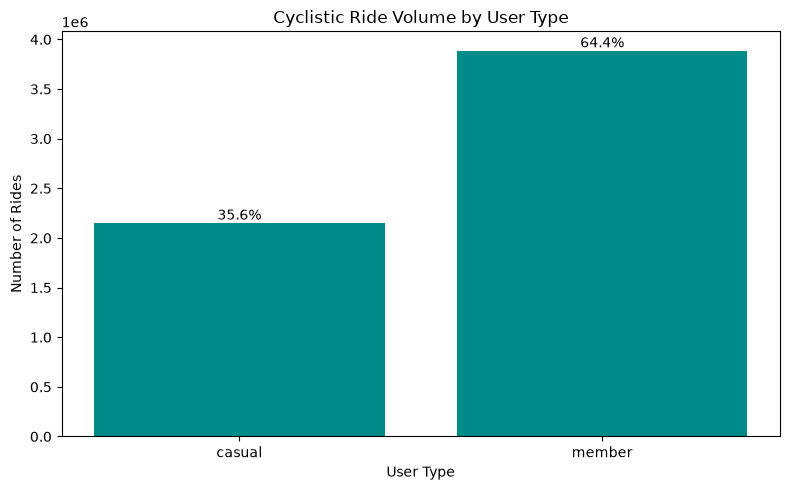

In [47]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    ride_counts["member_casual"],
    ride_counts["ride_count"],
    color="darkcyan"
)

plt.title("Cyclistic Ride Volume by User Type")
plt.xlabel("User Type")
plt.ylabel("Number of Rides")

for bar, percentage in zip(
    bars,
    ride_counts["percentage"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{percentage:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

The final dataset contained 6,037,933 rides. Of these, 3,886,892 rides were made by annual members, representing approximately 64.4% of all rides. Casual riders accounted for 2,151,041 rides, or approximately 35.6%.

This comparison indicates that annual members generated a larger share of total ride volume during the study period. However, these figures represent rides rather than unique users and therefore should not be interpreted as a comparison of the number of individuals in each user group.

### 5.3 Overall Usage — Monthly Ride Volume

Monthly ride volume was analyzed to identify seasonal patterns and determine whether usage differed between casual riders and annual members.

Because 128 rides started in July 2025 but were included in the August 2025 source file because they ended in August, these records were excluded from the monthly analysis. They were not considered invalid; they were outside the defined August 2025–July 2026 study period.

In [48]:
all_rides.columns

all_rides["year_month"] = all_rides["started_at"].dt.to_period("M").astype(str)

all_rides[["started_at", "year_month"]].head()

,started_at,year_month
0,2025-08-28 15:56:46.803,2025-08
1,2025-08-27 19:15:53.059,2025-08
2,2025-08-27 20:27:31.394,2025-08
3,2025-08-28 15:33:21.055,2025-08
4,2025-08-28 09:59:44.846,2025-08


In [49]:

analysis_rides = all_rides[
    (all_rides["year_month"] >= "2025-08") &
    (all_rides["year_month"] <= "2026-07")
].copy()

monthly_rides = (
    analysis_rides
    .groupby(["year_month", "member_casual"])
    .size()
    .reset_index(name="ride_count")
)

monthly_rides

,year_month,member_casual,ride_count
0,2025-08,casual,337878
1,2025-08,member,452439
2,2025-09,casual,265268
3,2025-09,member,449294
4,2025-10,casual,224038
5,2025-10,member,422058
6,2025-11,casual,99091
7,2025-11,member,257421
8,2025-12,casual,28090
9,2025-12,member,112455


**Which months have the highest and lowest usage?**

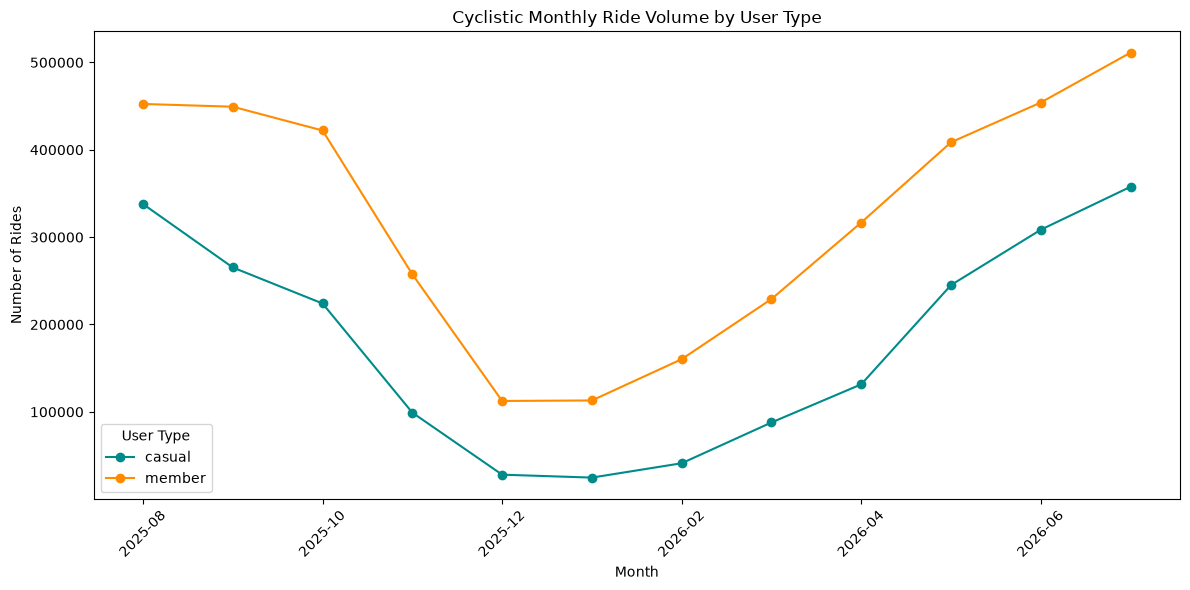

In [50]:
monthly_plot = monthly_rides.pivot(
    index="year_month",
    columns="member_casual",
    values="ride_count"
)

monthly_plot.plot(
    kind="line",
    marker="o",
    figsize=(12, 6),
    color=["darkcyan", "darkorange"]
)

plt.title("Cyclistic Monthly Ride Volume by User Type")
plt.xlabel("Month")
plt.ylabel("Number of Rides")
plt.legend(title="User Type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Ride volume varied considerably across the study period. Both user groups showed lower activity during the winter months and substantially higher activity during the spring and summer.

Annual members recorded more rides than casual riders in every month analyzed. The highest monthly volume for both groups occurred in July 2026, with 511,247 member rides and 357,681 casual rides.

The lowest monthly volume for casual riders occurred in January 2026, with 24,740 rides, while the lowest monthly volume for members occurred in December 2025, with 112,455 rides.

These results indicate a strong seasonal pattern in overall ride volume. However, monthly ride counts alone do not explain how the two user groups differ in their riding behavior. Further analysis of days of the week, time of day, ride duration, bike type, and station usage is therefore required.

### 5.4 Usage by Day of Week.

To examine whether riding behavior differed across the week, rides were grouped by `day_of_week` and `member_casual`. The analysis used `analysis_rides`, which contains only rides within the defined study period from August 2025 through July 2026.

Because the day names would otherwise be sorted alphabetically, the days were converted to an ordered categorical variable so that the results followed the natural Monday-to-Sunday sequence.

In [51]:
day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

weekly_rides = (
    analysis_rides
    .groupby(["day_of_week", "member_casual"])
    .size()
    .reset_index(name="ride_count")
)

weekly_rides["day_of_week"] = pd.Categorical(
    weekly_rides["day_of_week"],
    categories=day_order,
    ordered=True
)

weekly_rides = weekly_rides.sort_values("day_of_week")

weekly_rides

,day_of_week,member_casual,ride_count
2,Monday,casual,244329
3,Monday,member,538719
10,Tuesday,casual,238186
11,Tuesday,member,614331
12,Wednesday,casual,246200
13,Wednesday,member,622935
8,Thursday,casual,267760
9,Thursday,member,619457
0,Friday,casual,339790
1,Friday,member,581546


**Which days of the week have the highest usage?**

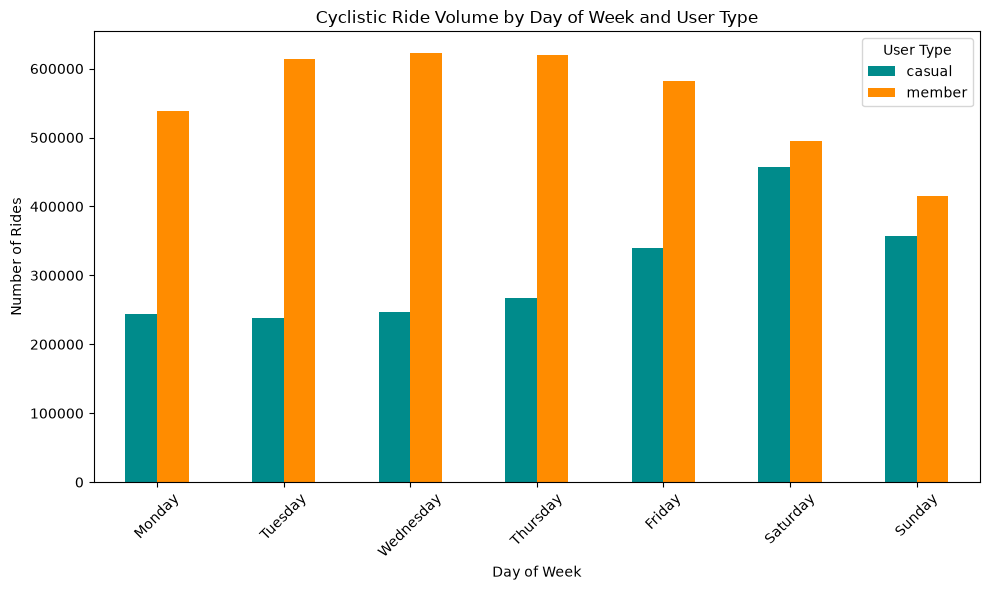

In [52]:
weekly_plot = weekly_rides.pivot(
    index="day_of_week",
    columns="member_casual",
    values="ride_count"
)

weekly_plot.plot(
    kind="bar",
    figsize=(10, 6),
    color=["darkcyan", "darkorange"]
)

plt.title("Cyclistic Ride Volume by Day of Week and User Type")
plt.xlabel("Day of Week")
plt.ylabel("Number of Rides")
plt.legend(title="User Type")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

The results showed different weekly usage patterns between casual riders and members.

* **Casual riders** recorded their highest ride volume on **Saturday**, with 457,395 rides.
* **Members** recorded their highest ride volume on **Wednesday**, with 622,935 rides.
* Casual ride volume increased toward the end of the week, particularly on **Friday and Saturday**.
* Members showed relatively high ride volumes throughout the weekdays, particularly from **Tuesday through Thursday**.
* The lowest ride volume for casual riders occurred on **Tuesday**, with 238,186 rides.
* The lowest ride volume for members occurred on **Sunday**, with 415,294 rides.

Overall, the results indicate that casual riders had a stronger concentration of rides toward the weekend, while members showed higher ride volumes during weekdays. This difference provides an initial indication that the two user groups may have distinct usage patterns. Further analysis of riding time, ride duration, and bike type can provide additional context for these differences.

### 5.5 Usage by Time of Day

To identify the hours when Cyclistic bikes were used most frequently, rides were grouped by `start_hour` and `member_casual`. The analysis focused on the hour in which each ride started.

In [53]:
hourly_rides = (
    analysis_rides
    .groupby(["start_hour", "member_casual"])
    .size()
    .reset_index(name="ride_count")
)

hourly_rides

,start_hour,member_casual,ride_count
0,0,casual,44600
1,0,member,36111
2,1,casual,29307
3,1,member,22007
4,2,casual,18730
5,2,member,13081
6,3,casual,10645
7,3,member,8461
8,4,casual,8521
9,4,member,9549


**At what times of day are bikes used most?**

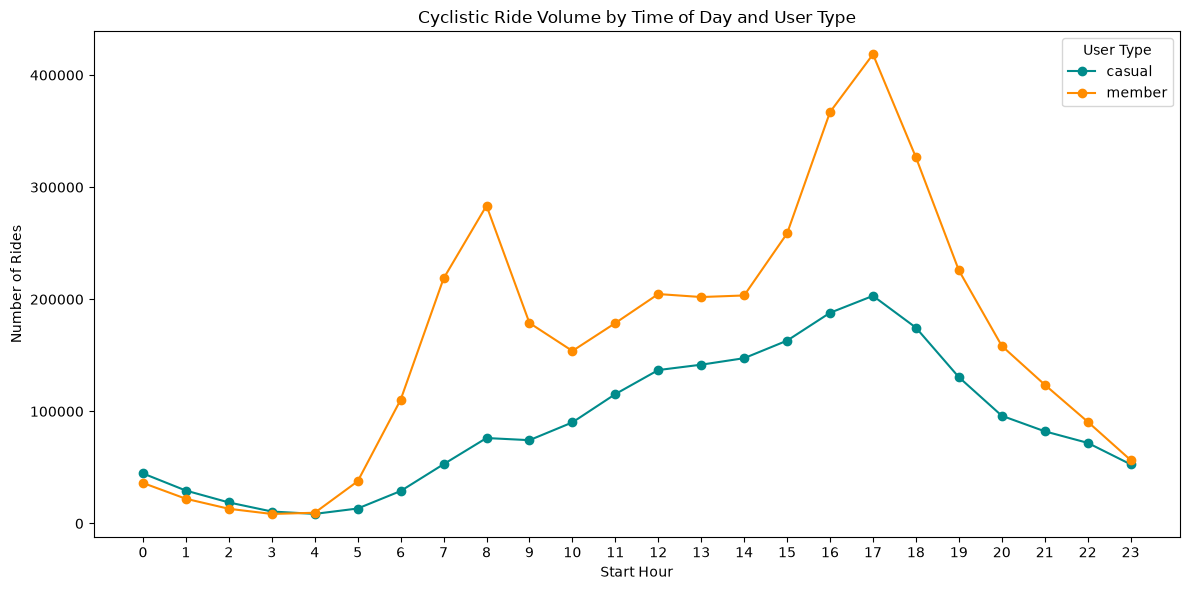

In [54]:
hourly_plot = hourly_rides.pivot(
    index="start_hour",
    columns="member_casual",
    values="ride_count"
)

hourly_plot.plot(
    kind="line",
    marker="o",
    figsize=(12, 6),
    color=["darkcyan", "darkorange"]
)

plt.title("Cyclistic Ride Volume by Time of Day and User Type")
plt.xlabel("Start Hour")
plt.ylabel("Number of Rides")
plt.legend(title="User Type")

plt.xticks(range(24))

plt.tight_layout()
plt.show()

The results showed distinct hourly usage patterns between casual riders and members.

Both user groups reached their highest ride volume at **5:00 p.m.** Members recorded **418,519 rides**, while casual riders recorded **203,028 rides** during this hour.

Member usage increased sharply during the morning. Ride volume increased from **37,628 rides at 5:00 a.m.** to **110,311 at 6:00 a.m.** and **218,538 at 7:00 a.m.** This increase was considerably more pronounced than the morning pattern observed among casual riders.

Casual rider activity increased more gradually throughout the day and became particularly high during the afternoon. Their ride volume increased from 147,436 rides at 2:00 p.m. to 163,098 at 3:00 p.m., 187,932 at 4:00 p.m., and 203,028 at 5:00 p.m.

For both groups, ride volume was lowest during the early morning hours, with the lowest observed values occurring around **4:00 a.m.** Casual riders recorded 8,521 rides at this hour, while members recorded 9,549 rides.

After the 5:00 p.m. peak, ride volume gradually decreased for both user groups.

Overall, the hourly distribution shows that members had a stronger morning increase and maintained higher ride volumes during most daytime hours, while casual riders showed a more gradual increase and relatively high activity during the afternoon. These differences provide additional evidence that casual riders and members have distinct usage patterns.

### 5.6 Ride Duration by User Type.

After analyzing ride volume and usage patterns by user type, ride duration was examined to determine whether casual riders and annual members differ in how long they use Cyclistic bikes.

In [55]:
avg_ride_length = (
    analysis_rides
    .groupby("member_casual")["ride_length"]
    .mean()
    .reset_index(name="avg_ride_length")
)

avg_ride_length

,member_casual,avg_ride_length
0,casual,21.221789
1,member,12.393075


In [56]:
ride_duration_stats = (
    analysis_rides
    .groupby("member_casual")["ride_length"]
    .agg(
        mean="mean",
        median="median"
    )
    .reset_index()
)

ride_duration_stats

,member_casual,mean,median
0,casual,21.221789,11.058067
1,member,12.393075,8.575350


**How long do rides last for each user type?**

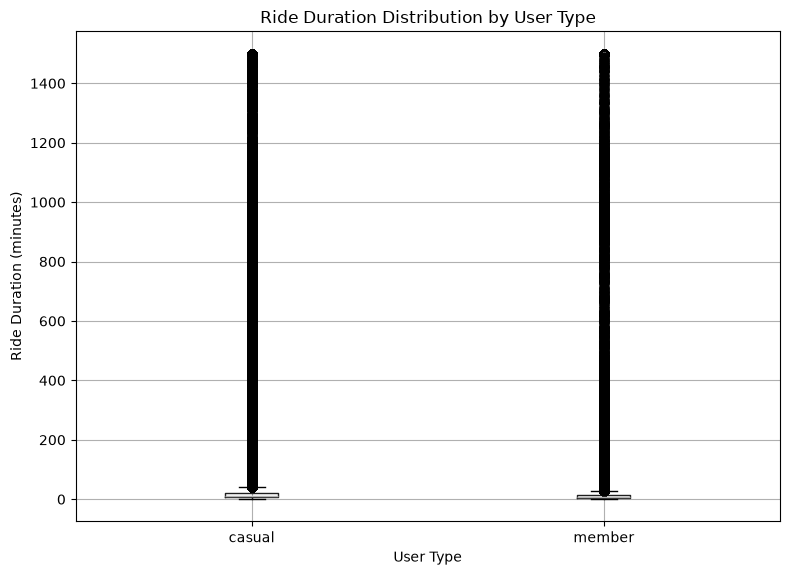

In [57]:
analysis_rides.boxplot(
    column="ride_length",
    by="member_casual",
    figsize=(8, 6)
)

plt.title("Ride Duration Distribution by User Type")
plt.suptitle("")
plt.xlabel("User Type")
plt.ylabel("Ride Duration (minutes)")

plt.tight_layout()
plt.show()

Because a small number of very long rides can compress the central distribution when visualized in a boxplot, rides of **60 minutes or less** were used for this visualization. This filtering was applied only to improve the readability of the plot and did not modify the main analytical dataset.

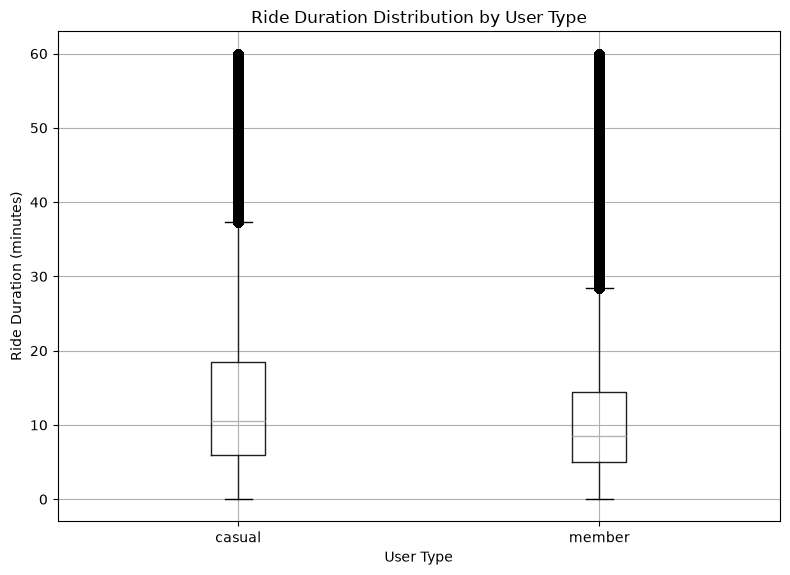

In [58]:
ride_duration_plot = analysis_rides[
    analysis_rides["ride_length"] <= 60
]

ride_duration_plot.boxplot(
    column="ride_length",
    by="member_casual",
    figsize=(8, 6)
)

plt.title("Ride Duration Distribution by User Type")
plt.suptitle("")
plt.xlabel("User Type")
plt.ylabel("Ride Duration (minutes)")

plt.tight_layout()
plt.show()

In [59]:
boxplot_stats = (
    ride_duration_plot
    .groupby("member_casual")["ride_length"]
    .quantile([0.25, 0.50, 0.75])
    .unstack()
    .rename(columns={
        0.25: "Q1",
        0.50: "Q2",
        0.75: "Q3"
    })
)

boxplot_stats["IQR"] = (
    boxplot_stats["Q3"] - boxplot_stats["Q1"]
)

display(boxplot_stats)

,Q1,Q2,Q3,IQR
member_casual,,,,
casual,5.983450,10.551817,18.494912,12.511462
member,4.996583,8.517617,14.386588,9.390004


**Interpretation of the boxplot**

The boxplot provides several important measurements:

- **Q1:** 25% of observations are below this value.
- **Q2 / Median**: 50% of observations are below this value.
- **Q3:** 75% of observations are below this value.
- **IQR:** The range between Q1 and Q3.
- **Whiskers:** Show the non-outlier range according to the boxplot rule.
- **Outliers:** Individual observations beyond the whiskers.

**For casual riders:**

- **Q1** ≈ 5.98 minutes
- **Median** ≈ 10.55 minutes
- **Q3** ≈ 18.49 minutes
- **IQR** ≈ 12.51 minutes

**For members:**

- **Q1** ≈ 5.00 minutes
- **Median** ≈ 8.52 minutes
- **Q3** ≈ 14.39 minutes
- **IQR** ≈ 9.39 minutes


Within the ≤60-minute visualization subset, casual riders had a higher median ride duration and a larger interquartile range than members, indicating longer and more variable typical ride durations.

In [60]:
boxplot_stats = (
    analysis_rides
    .groupby("member_casual")["ride_length"]
    .quantile([0.25, 0.50, 0.75])
    .unstack()
    .rename(columns={
        0.25: "Q1",
        0.50: "Q2",
        0.75: "Q3"
    })
)

boxplot_stats["IQR"] = (
    boxplot_stats["Q3"] - boxplot_stats["Q1"]
)

boxplot_stats

,Q1,Q2,Q3,IQR
member_casual,,,,
casual,6.17005,11.058067,20.274200,14.104150
member,5.01805,8.575350,14.569721,9.551671


### 5.8 Bike Type Usage by User Type


In [61]:
bike_type_counts = (
    analysis_rides
    .groupby(["member_casual", "rideable_type"])
    .size()
    .reset_index(name="ride_count")
)

bike_type_counts

,member_casual,rideable_type,ride_count
0,casual,classic_bike,612249
1,casual,electric_bike,1538704
2,member,classic_bike,1278904
3,member,electric_bike,2607948


In [62]:
bike_type_percent = bike_type_counts.copy()

bike_type_percent["percentage"] = (
    bike_type_percent
    .groupby("member_casual")["ride_count"]
    .transform(lambda x: x / x.sum() * 100)
)

bike_type_percent

,member_casual,rideable_type,ride_count,percentage
0,casual,classic_bike,612249,28.464081
1,casual,electric_bike,1538704,71.535919
2,member,classic_bike,1278904,32.903337
3,member,electric_bike,2607948,67.096663


In [63]:
bike_type_pivot = (
    bike_type_percent
    .pivot(
        index="rideable_type",
        columns="member_casual",
        values="percentage"
    )
)


bike_type_pivot

member_casual,casual,member
rideable_type,,
classic_bike,28.464081,32.903337
electric_bike,71.535919,67.096663


**What bike types do casual riders and members use?**

In [64]:
ax = bike_type_plot.plot(
    kind="bar",
    figsize=(8, 6),
    width=0.7,
    color=["darkcyan", "darkorange"]
)

plt.title("Bike Type Usage by User Type")
plt.xlabel("Bike Type")
plt.ylabel("Percentage of Rides")
plt.xticks(rotation=0)
plt.legend(title="User Type")

# Add percentage labels above each bar
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )

plt.tight_layout()
plt.show()

NameError: name 'bike_type_plot' is not defined

Electric bikes were the most commonly used bike type among both casual riders and members. They accounted for 71.54% of casual rides and 67.10% of member rides. Classic bikes represented 28.46% of casual rides and 32.90% of member rides. Overall, both user groups showed similar bike-type usage patterns, although casual riders had a slightly higher share of electric-bike usage.

### 5.9 Station Usage by User Type

In [ ]:
start_station_counts = (
    analysis_rides
    .dropna(subset=["start_station_name"])
    .groupby(["member_casual", "start_station_name"])
    .size()
    .reset_index(name="ride_count")
)


In [ ]:
top_start_stations = (
    start_station_counts
    .sort_values(
        ["member_casual", "ride_count"],
        ascending=[True, False]
    )
    .groupby("member_casual")
    .head(10)
)

display(top_start_stations)

,member_casual,start_station_name,ride_count
847,casual,Navy Pier,54838
338,casual,DuSable Lake Shore Dr & Monroe St,32546
793,casual,Michigan Ave & Oak St,22643
339,casual,DuSable Lake Shore Dr & North Blvd,19741
801,casual,Millennium Park,18271
1598,casual,Shedd Aquarium,17097
1710,casual,Theater on the Lake,16229
342,casual,Dusable Harbor,14757
787,casual,Michigan Ave & 8th St,11041
820,casual,Montrose Harbor,10524


In [ ]:
top_start_stations_plot = (
    top_start_stations
    .pivot(
        index="start_station_name",
        columns="member_casual",
        values="ride_count"
    )
    .fillna(0)
)

top_start_stations_plot

member_casual,casual,member
start_station_name,,
Canal St & Madison St,0.0,22974.0
Clark St & Elm St,0.0,17593.0
Clinton St & Jackson Blvd,0.0,19626.0
Clinton St & Madison St,0.0,19531.0
Clinton St & Washington Blvd,0.0,17564.0
DuSable Lake Shore Dr & Monroe St,32546.0,0.0
DuSable Lake Shore Dr & North Blvd,19741.0,0.0
Dusable Harbor,14757.0,0.0
Michigan Ave & 8th St,11041.0,0.0


In [ ]:
start_station_missing = analysis_rides["start_station_name"].isna().sum()
start_station_available = analysis_rides["start_station_name"].notna().sum()

print("Missing start station:", start_station_missing)
print("Available start station:", start_station_available)

Missing start station: 1273163
Available start station: 4764642


In [ ]:
start_station_missing_pct = (
    analysis_rides["start_station_name"].isna().mean() * 100
)

start_station_available_pct = (
    analysis_rides["start_station_name"].notna().mean() * 100
)

print(f"Missing start station: {start_station_missing_pct:.2f}%")
print(f"Available start station: {start_station_available_pct:.2f}%")

Missing start station: 21.09%
Available start station: 78.91%


In [ ]:
print("Total rows:", len(analysis_rides))
print("Missing:", analysis_rides["start_station_name"].isna().sum())
print("Available:", analysis_rides["start_station_name"].notna().sum())
print("Sum:", (
    analysis_rides["start_station_name"].isna().sum()
    + analysis_rides["start_station_name"].notna().sum()
))

Total rows: 6037805
Missing: 1273163
Available: 4764642
Sum: 6037805


Starting-station information was evaluated before conducting the station analysis.

For start_station_name:

- **Missing:** 1,273,163
- **Available:** 4,764,642
- **Total:** 6,037,805

Therefore:

- **Available:** 78.91%
- **Missing:** 21.09%

The calculation was validated:

1,273,163 + 4,764,642 = 6,037,805

Because 78.91% of analyzed rides had a recorded starting station, the station analysis provides a substantial descriptive view of station usage.

However, the results represent only rides with available starting-station information.

The rides with missing station information were retained in the main analytical dataset.

### 5.10 Top Starting Stations — Casual Riders

In [ ]:
casual_top10 = (
    top_start_stations[
        top_start_stations["member_casual"] == "casual"
    ]
    .sort_values("ride_count", ascending=True)
)

display(casual_top10)

,member_casual,start_station_name,ride_count
820,casual,Montrose Harbor,10524
787,casual,Michigan Ave & 8th St,11041
342,casual,Dusable Harbor,14757
1710,casual,Theater on the Lake,16229
1598,casual,Shedd Aquarium,17097
801,casual,Millennium Park,18271
339,casual,DuSable Lake Shore Dr & North Blvd,19741
793,casual,Michigan Ave & Oak St,22643
338,casual,DuSable Lake Shore Dr & Monroe St,32546
847,casual,Navy Pier,54838


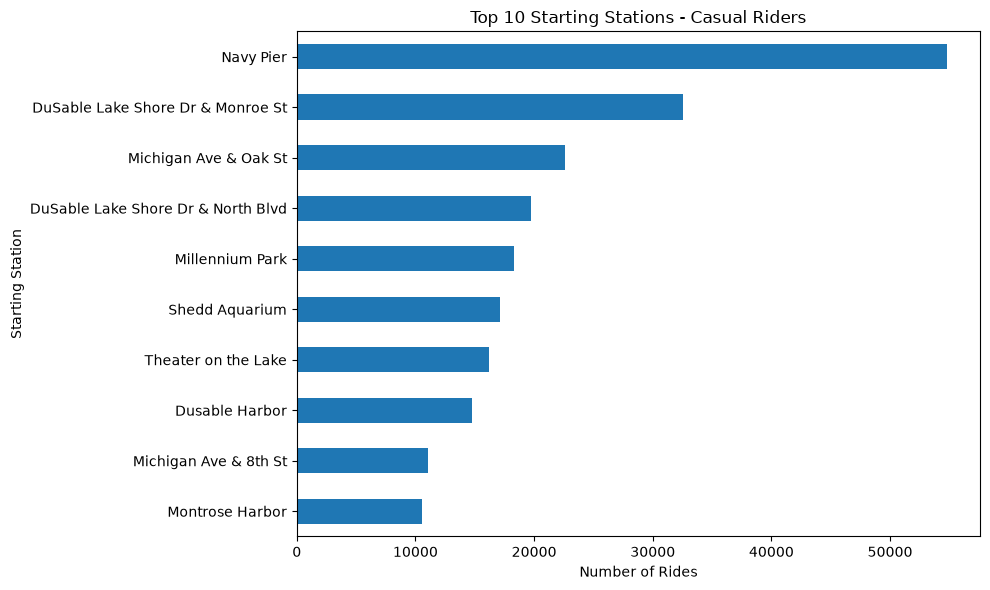

In [ ]:
casual_top10.plot(
    kind="barh",
    x="start_station_name",
    y="ride_count",
    figsize=(10, 6),
    legend=False
)

plt.title("Top 10 Starting Stations - Casual Riders")
plt.xlabel("Number of Rides")
plt.ylabel("Starting Station")
plt.tight_layout()
plt.show()

Several of the most frequently used starting stations among casual riders are located near waterfront, park, harbor, or recreational destinations.

However, the data does not identify the purpose of each trip. Therefore, these locations should not automatically be interpreted as evidence that the trips were recreational or tourism-related.

### 5.11 Top Starting Stations — Members

In [ ]:
member_top10 = (
    top_start_stations[
        top_start_stations["member_casual"] == "member"
    ]
    .sort_values("ride_count", ascending=True)
)

display(member_top10)

,member_casual,start_station_name,ride_count
3660,member,Wells St & Hubbard St,16873
2109,member,Clinton St & Washington Blvd,17564
2079,member,Clark St & Elm St,17593
3661,member,Wells St & Huron St,18136
2105,member,Clinton St & Madison St,19531
2103,member,Clinton St & Jackson Blvd,19626
3658,member,Wells St & Elm St,19657
3657,member,Wells St & Concord Ln,19681
3558,member,State St & Chicago Ave,21642
2020,member,Canal St & Madison St,22974


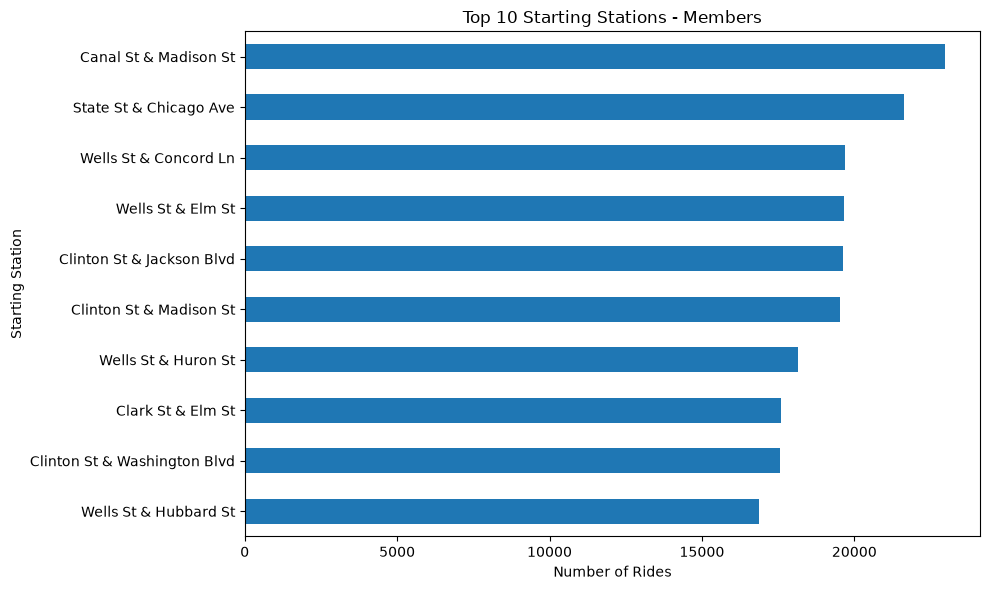

In [ ]:
member_top10.plot(
    kind="barh",
    x="start_station_name",
    y="ride_count",
    figsize=(10, 6),
    legend=False
)

plt.title("Top 10 Starting Stations - Members")
plt.xlabel("Number of Rides")
plt.ylabel("Starting Station")
plt.tight_layout()
plt.show()

Several of the most frequently used member starting stations were concentrated around central Chicago and major urban streets.

This differs from the pattern observed among the top casual starting stations.

Starting-station patterns differed between casual riders and members. Several high-use casual stations were located near waterfront and recreational destinations, while member stations were more concentrated around central urban areas.

### 5.12 Summary of User Behavior Patterns

The analysis identified several differences in usage patterns between casual riders and annual members.

First, annual members consistently accounted for a larger share of total rides throughout the analyzed period. Their usage also showed a more consistent pattern across the year, while casual ride volume varied more substantially between high- and low-activity months.

Second, the two user types showed different patterns by day of the week. Casual rides were highest on Saturdays, followed by Sundays and Fridays, whereas member rides were highest from Tuesday through Thursday. This indicates that the distribution of rides across the week differs between the two user groups.

Time-of-day patterns also differed. Member activity showed pronounced increases during the morning and late afternoon, while casual activity was more distributed throughout the day and reached higher levels during the afternoon and evening.

Ride duration provided another important distinction. Within the rides included in the ≤60-minute visualization, casual riders had a higher median duration and a wider interquartile range than members. This indicates that casual rides were typically longer and more variable within the central distribution.

Electric bikes represented the majority of rides for both user types. However, the share of electric-bike rides was slightly higher among casual riders than members.

Finally, starting-station patterns differed between the groups. Several of the most frequently used starting stations among casual riders were located near waterfront, park, and recreational destinations, while members' most frequently used stations were concentrated primarily around central Chicago and major urban streets. Because station information was missing for 21.09% of rides, these findings describe only rides with a recorded starting station.

## 6. Share

### 6.1 Key Findings

- **1. Annual members generate more rides overall**

Annual members recorded more rides than casual riders throughout the analyzed period. This difference was consistent across the months included in the analysis.

**Business relevance:** Members represent the larger and more consistent user segment, while casual riders represent the segment with potential for membership conversion.

- **2. Casual and member riders show different weekly patterns**

Casual riders recorded their highest ride volume on Saturdays, followed by Sundays and Fridays. In contrast, member rides were highest from Tuesday through Thursday.

**Business relevance:** The distribution of rides across the week differs between user types, suggesting that membership communication could consider when casual riders are most active.

- **3. Usage patterns differ throughout the day**

Member activity showed pronounced increases during the morning and late afternoon, while casual activity was more distributed throughout the day and reached higher levels during the afternoon and evening.

**Business relevance:** The different hourly patterns provide an additional way to identify periods when casual riders are particularly active and could be exposed to membership messaging.

- **4. Casual rides tend to be longer and more variable**

Within the rides included in the ≤60-minute visualization, casual riders had a median ride duration of approximately 10.55 minutes, compared with 8.52 minutes for members. Casual riders also had a larger interquartile range.

**Business relevance:** Ride duration represents one measurable difference between the two user groups and can be considered when designing membership communication.

- **5. Electric bikes dominate both user groups**

Electric bikes represented the majority of recorded rides for both groups, accounting for 71.54% of casual rides and 67.10% of member rides.

**Business relevance:** Since electric bikes are widely used by both groups, membership strategies could be designed around the existing usage patterns rather than assuming that casual riders primarily use a different type of bicycle.

### 6.2 Business Insights

- **Insight 1 — Casual riders have identifiable periods of higher activity**

Casual ride volume was particularly high on Fridays, Saturdays, and Sundays, with Saturday showing the highest number of casual rides.

This suggests that weekends and the transition into the weekend are important periods of casual-rider activity. These periods could therefore be considered when planning membership communication or promotional campaigns.

Data basis: Day-of-week analysis.


- **Insight 2 — Casual riders generally take longer rides**

Casual riders had a median ride duration of approximately 10.55 minutes, compared with 8.52 minutes for members within the ≤60-minute visualization subset.

The larger interquartile range among casual riders also indicates greater variability in their ride durations.

This difference can be used to tailor membership messaging around the usage patterns already observed among casual riders, rather than assuming that casual and member rides have the same characteristics.

Data basis: Ride-duration analysis.

- **Insight 3 — Casual usage increases substantially during warmer months**

Both user groups showed strong seasonal variation. Ride volume increased considerably during spring and summer and decreased during the colder months.

Casual ridership reached particularly high levels in May, June, and July, with July recording the highest casual ride volume in the analyzed period.

This indicates that seasonal campaigns could be considered when planning membership-conversion initiatives.

Data basis: Monthly ride-volume analysis.

- **Insight 4 — Casual and member riders have different hourly patterns**

Member rides showed pronounced activity during the morning and late afternoon, while casual rides were more distributed throughout the day and showed relatively high activity during the afternoon and evening.

This provides another behavioral dimension that could be used to determine when membership-related messages are presented to casual riders.

Data basis: Hourly ride-volume analysis.

- **Insight 5 — Electric bikes are relevant to both user groups**

Electric bikes represented the majority of rides for both casual riders and members, accounting for 71.54% of casual rides and 67.10% of member rides.

Therefore, electric-bike usage is not unique to casual riders. Any membership strategy involving bike type should recognize that electric bikes are already widely used by both segments.

Data basis: Bike-type analysis.

## 6.3 Executive Summary

The analysis of Cyclistic's ride data from August 2025 through July 2026 identified clear behavioral differences between casual riders and annual members. Annual members generated more rides overall, while casual riders showed higher activity during weekends and longer typical ride durations. Both groups displayed strong seasonal patterns, with substantially higher usage during spring and summer. Hourly usage also differed between the two groups, with members showing stronger morning and late-afternoon activity and casual riders showing greater activity during the afternoon and evening. Electric bikes represented the majority of rides for both groups.

These findings indicate that casual riders and annual members do not use the Cyclistic service in exactly the same way. The observed differences in timing, duration, and usage patterns can therefore be considered when developing targeted strategies to encourage casual riders to purchase annual memberships.


## 7. Act

The Act phase translates the findings from the analysis into potential actions that Cyclistic could consider to increase annual memberships among casual riders.

The recommendations below are based on the behavioral patterns identified in the analyzed data. They should be considered as data-informed opportunities rather than guaranteed outcomes because the analysis does not directly measure the effectiveness of specific marketing campaigns.


### 7.1 Recommendation 1 — Target Casual Riders During High-Activity Periods

Casual riders recorded their highest ride volumes on Fridays, Saturdays, and Sundays.

Cyclistic could consider increasing membership-related communication during these periods, when casual-rider activity is higher.

Potential channels could include:

- In-app membership messages
- Digital promotions
- Email campaigns
- Membership information displayed through the Cyclistic service

**Rationale:** The objective would be to present membership information when casual riders are already actively using the service.

**Data basis:** Day-of-week analysis.


### 7.2 Recommendation 2 — Use Seasonal Campaigns

Casual ride volume increased substantially during spring and summer, with July recording the highest casual ride volume in the analyzed period.

Cyclistic could consider increasing membership campaigns before and during the months with higher casual activity.

A potential campaign structure could be:

**Spring — Awareness**

Introduce the benefits of annual membership as ride volume begins to increase.

**Early summer — Conversion**

Increase membership-focused communication as casual usage grows.

**Peak summer — Reinforcement**

Continue communicating membership options during periods of particularly high casual activity.

**Rationale:** A seasonal approach would align membership communication with periods when casual riders are already using the service more frequently.

**Data basis:** Monthly ride-volume analysis.


### 7.3 Recommendation 3 — Develop Messaging Around Casual Ride Patterns

Casual riders had a higher median ride duration than members within the ≤60-minute visualization subset:

- Casual: **10.55 minutes**
- Member: **8.52 minutes**

Casual riders also had a larger interquartile range.

Cyclistic could consider developing membership messaging that reflects the actual usage patterns observed among casual riders.

The objective would be to communicate the recurring value of membership without assuming a specific motivation for individual rides.

**Rationale:** The objective would be to make membership communication more relevant to the behavior of the target segment.

**Data basis:** Ride-duration analysis.


### 7.4 Recommendation 4 — Consider Time-of-Day Targeting

The hourly analysis identified different activity patterns between casual riders and members.

Casual riders showed relatively higher activity during the afternoon and evening, while members showed pronounced activity during the morning and late afternoon.

Cyclistic could consider testing membership messages during periods when casual activity is particularly high.

**Rationale:** Time-of-day targeting could allow Cyclistic to reach casual riders while they are actively using the service.

**Data basis:** Hourly ride-volume analysis.


### 7.5 Recommendation 5 — Maintain Focus on Electric-Bike Users

Electric bikes represented:

- **71.54% of casual rides**
- **67.10% of member rides**

Because electric bikes were the most commonly recorded bike type for both groups, Cyclistic could consider incorporating electric-bike usage into membership communication.

However, the analysis does not establish that electric-bike users are more likely to become members. Therefore, this finding should be used as a segmentation consideration rather than as evidence of a causal relationship.

**Rationale:** Electric-bike users represent a substantial portion of both segments.

**Data basis:** Bike-type analysis.


### 7.6 Recommended Strategy

Based on the findings, Cyclistic could consider combining the previous recommendations into a behavior-based membership campaign.

#### Step 1 — Identify High-Activity Periods

Focus membership communication around:

- Fridays
- Saturdays
- Sundays
- Spring and summer months
- Afternoon and evening periods

#### Step 2 — Target Casual Riders

Prioritize communication toward users identified as casual riders, since they are the segment that Cyclistic is seeking to convert into annual members.

#### Step 3 — Use Behavior-Relevant Messaging

Messaging could reference the value of recurring bike usage and the convenience of annual membership without assuming a specific motivation for individual rides.

#### Step 4 — Test Different Approaches

Cyclistic could test different messages, timing, and promotional approaches rather than assuming that one strategy will work for all casual riders.

#### Step 5 — Measure Conversion

Future analysis should compare:

- Number of casual riders exposed to the campaign
- Number of membership purchases
- Conversion rate
- Campaign timing
- User activity before and after exposure

This would allow Cyclistic to evaluate whether the proposed strategies are actually associated with increased membership conversion.


### 7.7 Limitations and Considerations

#### 1. The Analysis Is Observational

The dataset describes historical ride behavior. It does not demonstrate that a specific marketing strategy will cause casual riders to become members.

#### 2. User Motivations Are Not Directly Available

The data contains information about rides, but it does not explain why a person took a particular ride.

For example, we can observe that casual riders use bikes more frequently on weekends, but we cannot conclude from this alone that their trips were specifically for tourism, recreation, or leisure.

#### 3. Missing Station Information

Starting-station information was unavailable for **21.09% of analyzed rides**.

Therefore, station-level conclusions are based only on rides with available starting-station information.

#### 4. Ride Duration Visualization

The ≤60-minute filter was used to improve the readability of the ride-duration visualization. It did not modify the main analytical dataset.

#### 5. Additional Data Would Improve the Analysis

Future analysis could benefit from information such as:

- Membership conversion history
- Customer demographics
- Marketing campaign exposure
- Membership purchase date
- Customer location
- Campaign response
- Revenue by user type

These variables could help evaluate which casual riders are most likely to convert and whether specific campaigns influence membership adoption.


### 7.8 Final Recommendation

Cyclistic should consider a targeted, behavior-based approach to increasing annual memberships among casual riders. The analysis shows that casual riders have distinct patterns of usage, including higher weekend activity, longer typical rides, strong seasonal variation, and greater afternoon and evening activity. These differences provide opportunities to align membership communication with periods of higher casual-rider engagement.

Rather than applying a single strategy to all casual riders, Cyclistic could test different messages and campaign timings based on observed usage patterns. Future analysis should then measure membership conversion and campaign performance to determine which approaches are associated with higher conversion rates.


## 8. Conclusion

This analysis examined Cyclistic's bike-share usage from August 2025 through July 2026 to identify differences between casual riders and annual members and explore opportunities to increase annual memberships.

The analysis found clear differences in usage patterns between the two groups. Annual members generated more rides overall, while casual riders showed higher activity during weekends, longer typical ride durations, and stronger afternoon and evening activity. Both groups demonstrated substantial seasonal variation, with ride volume increasing during spring and summer. Electric bikes represented the majority of rides for both user types, while starting-station patterns also differed between the groups.

These findings provide a data-driven basis for developing targeted membership strategies. Cyclistic could consider focusing membership communication on periods of higher casual activity, particularly weekends, warmer months, and afternoon or evening periods. However, these recommendations should be tested and evaluated using future campaign and conversion data rather than treated as guaranteed outcomes.

Overall, the analysis demonstrates how historical ride data can be used to identify behavioral differences between customer segments and generate actionable opportunities for business decision-making.